In [1]:
# =============================================================================
# 1. IMPORTS
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import os
import time
from IPython.display import clear_output
from tqdm.notebook import tqdm
import pandas as pd

In [2]:
# =============================================================================
# 2. CONFIGURATION
# =============================================================================
# All your settings are now in one place for easy modification
CONFIG = {
    "train_dir": '/kaggle/input/doctors-handwritten-prescription-dataset/dataset/TRAIN',
    "valid_dir": '/kaggle/input/doctors-handwritten-prescription-dataset/dataset/VALIDATE',
    "test_dir": '/kaggle/input/doctors-handwritten-prescription-dataset/dataset/TEST',
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 32,
    "num_epochs": 50,
    "patience": 7,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 2,
    "fig_size": (30, 12)
}

In [3]:
# =============================================================================
# 3. HELPER FUNCTIONS (Modular and Reusable)
# =============================================================================

def get_dataloaders(train_dir, valid_dir, test_dir, image_size, batch_size, num_workers):
    """Creates and returns the training, validation, and test dataloaders."""
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'valtest': transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }
    
    image_datasets = {
        'train': datasets.ImageFolder(train_dir, data_transforms["train"]),
        'val': datasets.ImageFolder(valid_dir, data_transforms["valtest"]),
        'test': datasets.ImageFolder(test_dir, data_transforms["valtest"])
    }
    
    dataloaders = {
        'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=num_workers),
        'val': DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=False, num_workers=num_workers),
        'test': DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False, num_workers=num_workers)
    }
    
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
    class_names = image_datasets['train'].classes
    return dataloaders, dataset_sizes, class_names

def get_model(model_name, num_classes, pretrained=True):
    """Loads a pre-trained model and replaces the final layer."""
    weights = 'IMAGENET1K_V1' if pretrained else None
    model = None
    
    if model_name == 'vgg16':
        model = models.vgg16(weights=weights)
        for param in model.parameters(): param.requires_grad = False
        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes))
    
    elif model_name == 'resnet18':
        model = models.resnet18(weights=weights)
        for param in model.parameters(): param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=weights)
        for param in model.parameters(): param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    else:
        raise ValueError(f"Model name '{model_name}' is not supported.")
        
    return model

def live_plot(history, model_name, figsize):
    """Displays a live plot of training history."""
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    # Customize your colors here if you wish
    ax1.plot(history['train_acc'], label='Train Accuracy', color='crimson')
    ax1.plot(history['val_acc'], label='Validation Accuracy', color='goldenrod')
    ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epochs'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)
    ax2.plot(history['train_loss'], label='Train Loss', color='crimson')
    ax2.plot(history['val_loss'], label='Validation Loss', color='goldenrod')
    ax2.set_title('Model Loss'); ax2.set_xlabel('Epochs'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)
    plt.suptitle(f'Live Training Progress - {model_name.upper()}', fontsize=25)
    plt.show()

In [4]:
# =============================================================================
# 4. CORE TRAINING AND EVALUATION LOGIC
# =============================================================================

def train_model(model, model_name, dataloaders, dataset_sizes, config):
    """The main training loop."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    epochs_no_improve = 0
    save_path = f'{model_name}_best_model.pth'

    for epoch in range(config["num_epochs"]):
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0
            
            progress_bar = tqdm(dataloaders[phase], desc=f'{phase.title()} Epoch {epoch+1}/{config["num_epochs"]}')
            for inputs, labels in progress_bar:
                inputs, labels = inputs.to(config["device"]), labels.to(config["device"])
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward(); optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                progress_bar.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            
            if phase == 'val':
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), save_path)
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        
        live_plot(history, model_name, config["fig_size"])
        print(f"Epoch {epoch+1}/{config['num_epochs']} -> Train Acc: {history['train_acc'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")
        
        if epochs_no_improve >= config["patience"]:
            print(f'Early stopping triggered after {config["patience"]} epochs with no improvement.')
            break
            
    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(torch.load(save_path))
    return model, history

def evaluate_model(model, dataloaders, class_names, config):
    """Evaluates the model on the test set and returns key metrics."""
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloaders['test'], desc="Evaluating on Test Set"):
            inputs, labels = inputs.to(config["device"]), labels.to(config["device"])
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    y_true, y_scores = np.array(y_true), np.array(y_scores)
    y_pred = np.argmax(y_scores, axis=1)

    # Calculate metrics
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    kappa = cohen_kappa_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_scores, multi_class="ovr", average="macro")
    
    # Print and plot
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))
    print(f"Cohen's Kappa Score: {kappa:.4f}")
    print(f"Macro-averaged One-vs-Rest AUC score: {auc:.4f}")

    plt.figure(figsize=config["fig_size"])
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

    return report, kappa, auc

In [5]:
# =============================================================================
# 5. MAIN EXPERIMENT RUNNER
# =============================================================================

def run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, config):
    """A master function to run a full train-and-evaluate experiment on a given model."""
    print(f"========== STARTING EXPERIMENT: {model_name.upper()} ==========")
    
    # 1. Ensure model is on the correct device
    model.to(config["device"])
    
    # 2. Train model
    # Note: The optimizer and scheduler are now created inside train_model
    trained_model, history = train_model(model, model_name, dataloaders, dataset_sizes, config)
    
    # 3. Evaluate model
    report, kappa, auc = evaluate_model(trained_model, dataloaders, class_names, config)
    
    # 4. Package results
    results = {
        "history": history,
        "test_accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "kappa": kappa,
        "auc": auc
    }
    print(f"========== FINISHED EXPERIMENT: {model_name.upper()} ==========\n")
    return results

---

In [6]:
# =============================================================================
# 6. EXECUTION 
# =============================================================================

all_results = {}

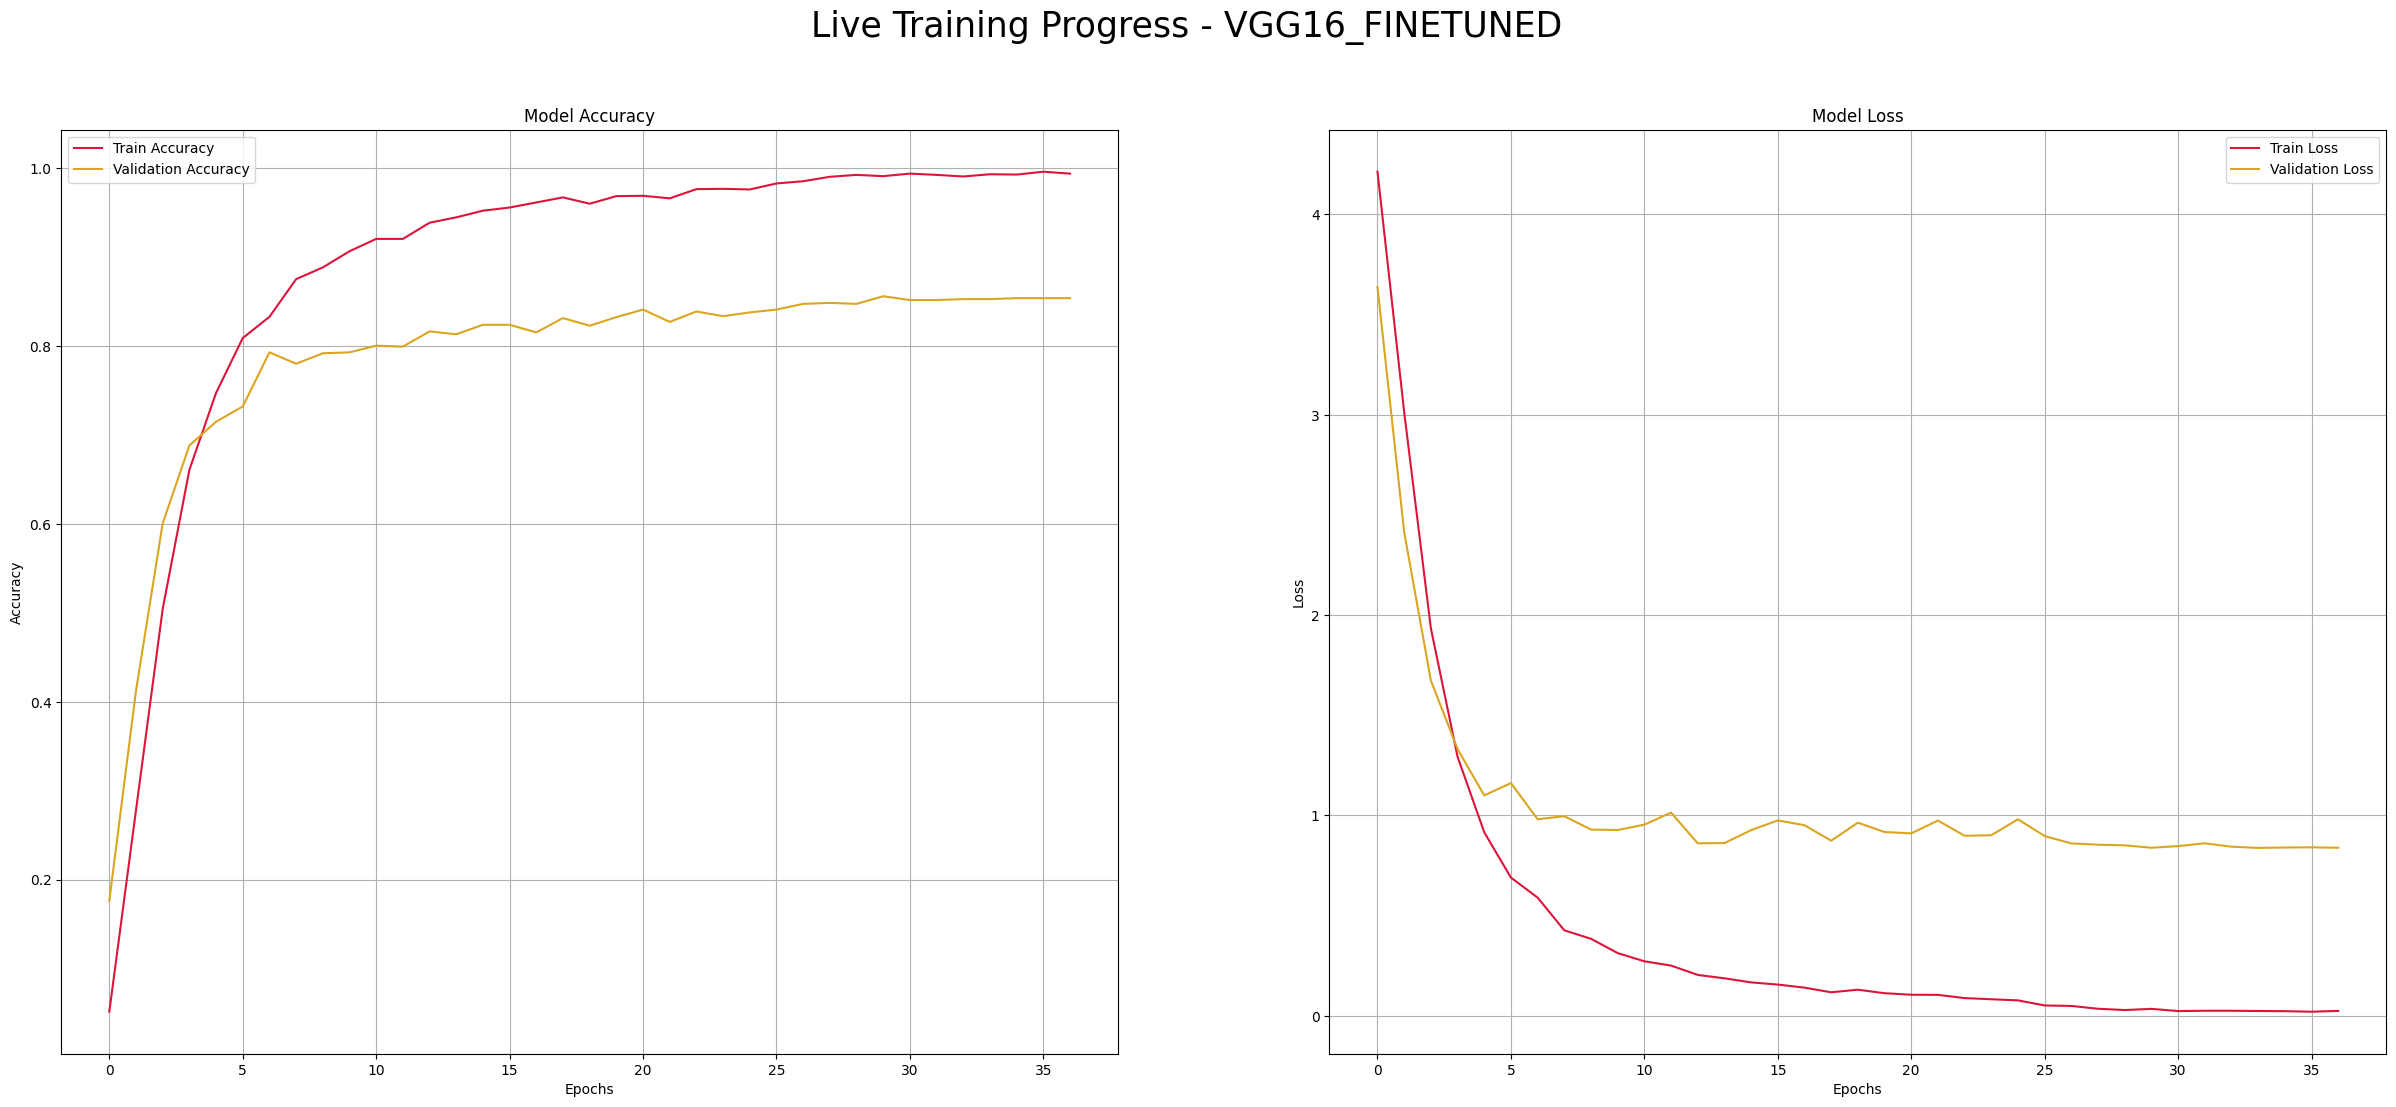

Epoch 37/50 -> Train Acc: 0.9936 | Val Acc: 0.8536
Early stopping triggered after 7 epochs with no improvement.

Training complete in 7m 49s
Best val Acc: 0.855769


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       1.00      1.00      1.00        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.80      1.00      0.89        12
      Amodis       0.80      1.00      0.89        12
     Atrizin       1.00      0.75      0.86        12
      Axodin       1.00      1.00      1.00        12
          Az       0.71      1.00      0.83        12
  Azithrocin       0.92      0.92      0.92        12
       Azyth       1.00      0.83      0.91        12
      Bacaid       0.86      1.00      0.92        12
    Backtone       0.79      0.92      0.85        12
    Baclofen       0.67      0.67      0.67        12
      Baclon       0.25      0.08      0.12        12
      Bacmax       1.00      0.83      0.91        12
       Beklo       1.00      1.00      1.00        12
     Bicozin       0.67      0.83      0.74        12
    Canazole       0.80      1.00      0.89        12
   

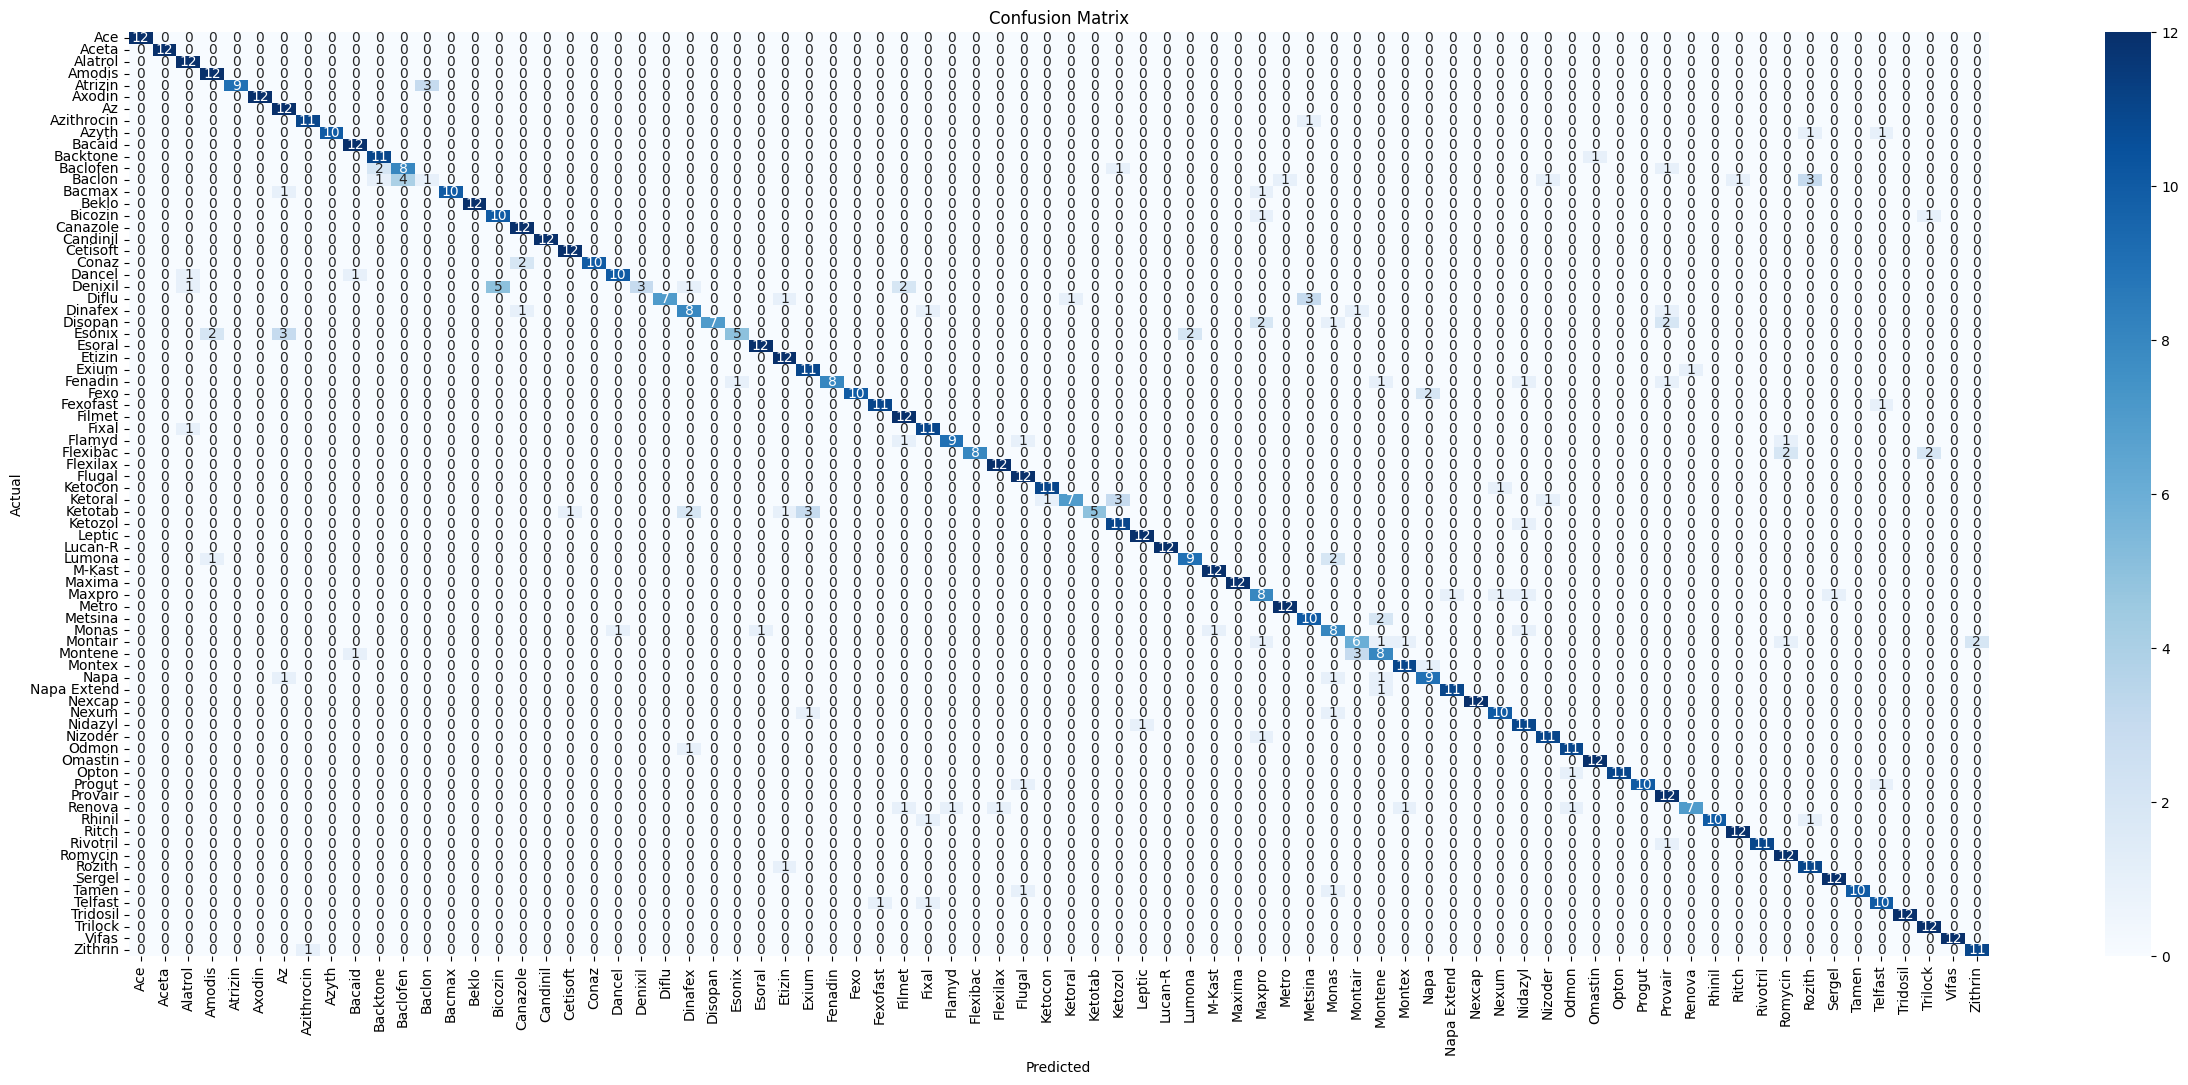

========== FINISHED EXPERIMENT: VGG16_FINETUNED ==========



In [7]:
# --- Experiment 1: VGG16 with Fine-Tuning ---
print("--- Setting up VGG16 Experiment ---")
model_name = 'vgg16_finetuned'
image_size = 224

# Get data loaders for this experiment's image size
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure your model
vgg_model = models.vgg16(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in vgg_model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block and the classifier for fine-tuning
for param in vgg_model.features[24:].parameters():
    param.requires_grad = True
for param in vgg_model.classifier.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = vgg_model.classifier[0].in_features
vgg_model.classifier = nn.Sequential(
    nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes))

# Run the experiment
all_results[model_name] = run_experiment(vgg_model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

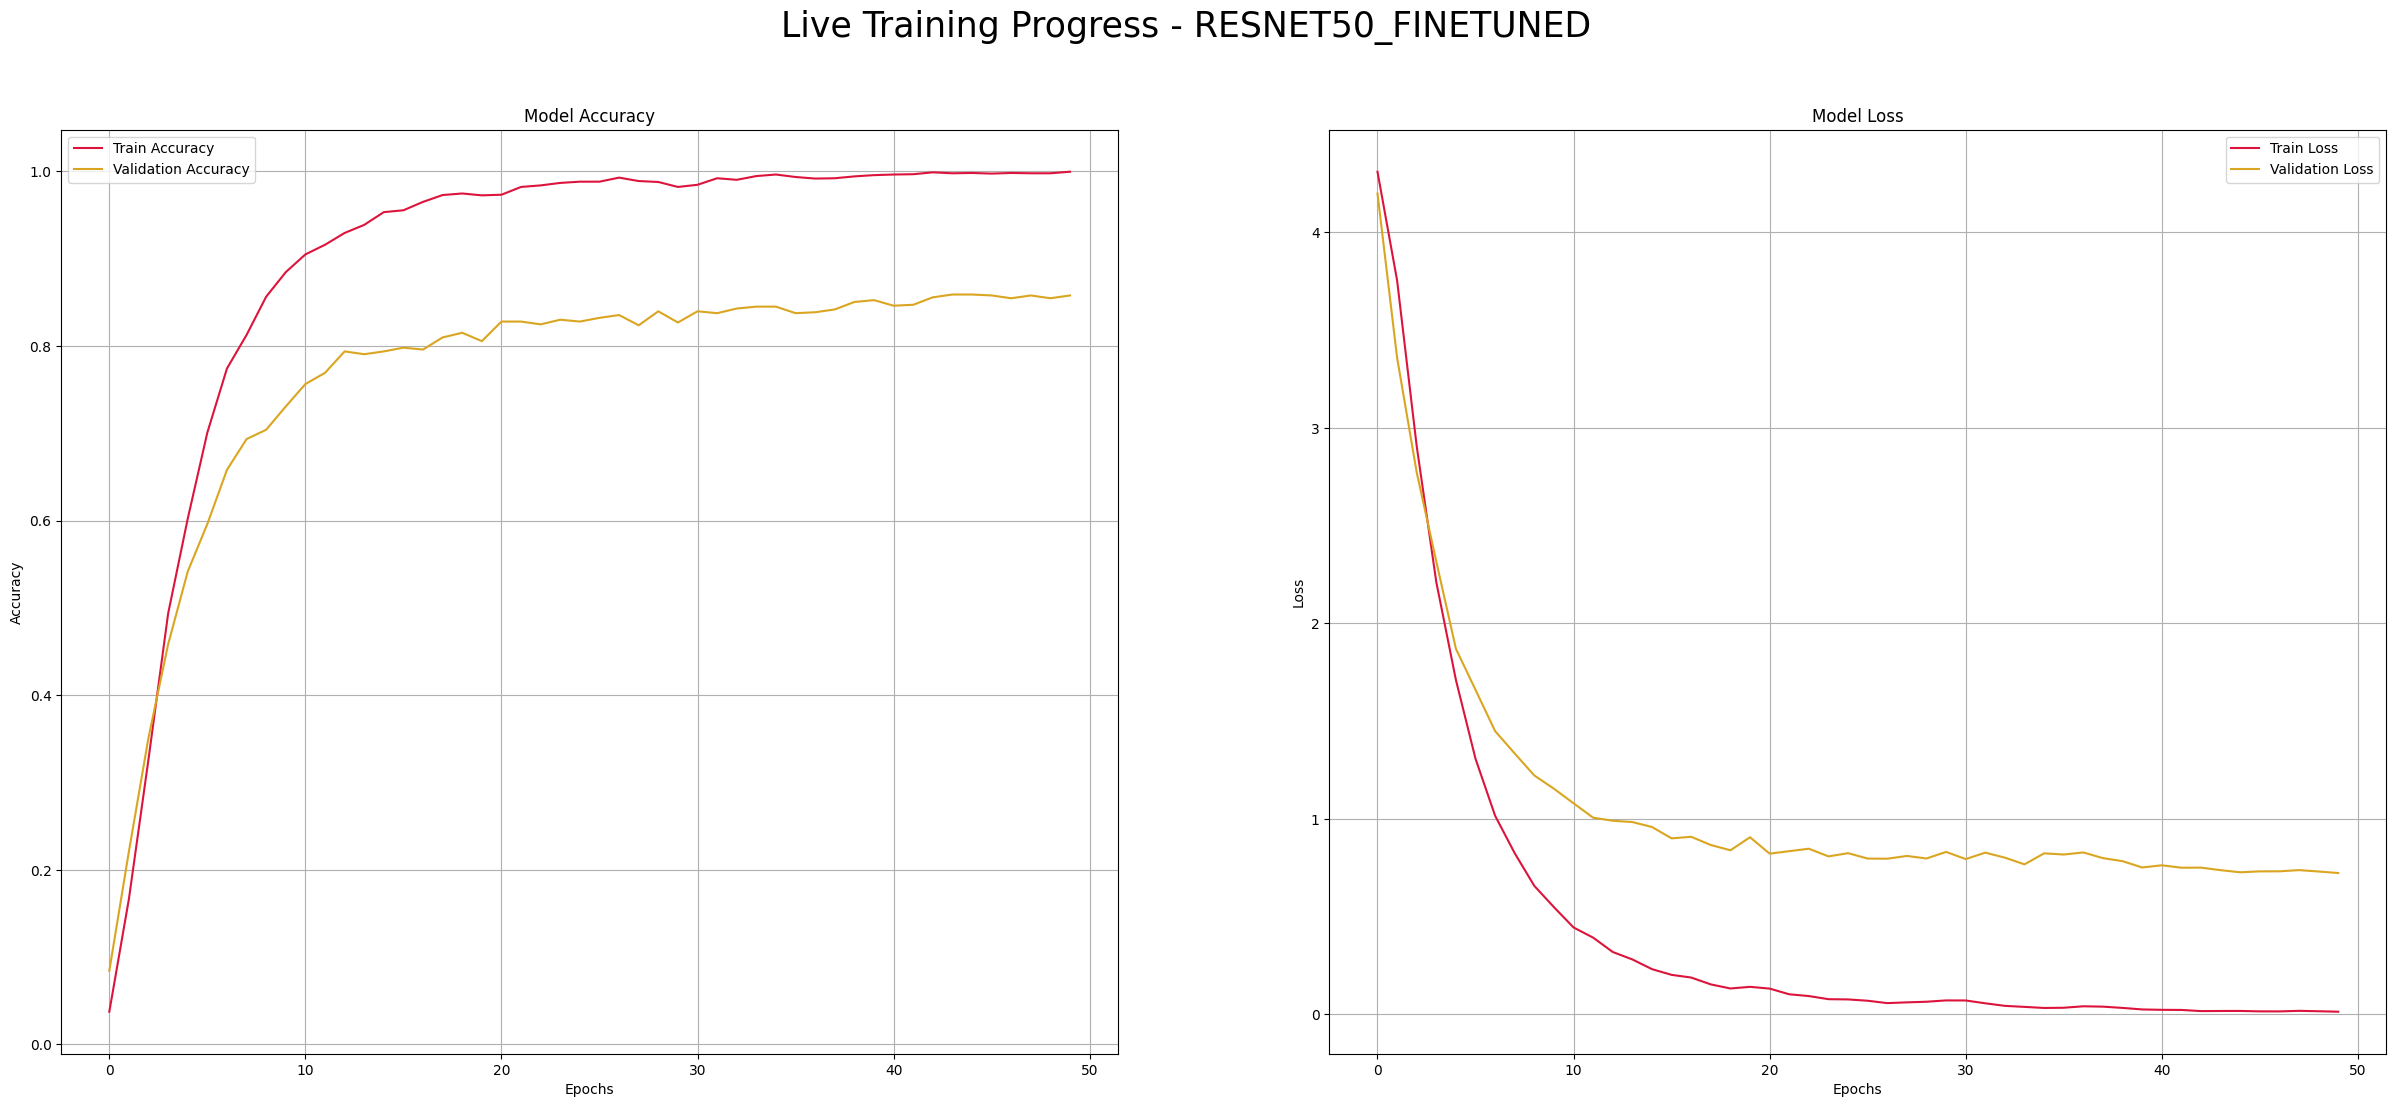

Epoch 50/50 -> Train Acc: 0.9996 | Val Acc: 0.8579

Training complete in 8m 59s
Best val Acc: 0.858974


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       0.92      0.92      0.92        12
       Aceta       0.92      1.00      0.96        12
     Alatrol       0.79      0.92      0.85        12
      Amodis       0.86      1.00      0.92        12
     Atrizin       0.69      0.75      0.72        12
      Axodin       0.79      0.92      0.85        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.83      0.83      0.83        12
       Azyth       1.00      1.00      1.00        12
      Bacaid       0.75      1.00      0.86        12
    Backtone       0.83      0.83      0.83        12
    Baclofen       0.71      0.83      0.77        12
      Baclon       0.83      0.42      0.56        12
      Bacmax       0.92      0.92      0.92        12
       Beklo       0.92      1.00      0.96        12
     Bicozin       0.69      0.75      0.72        12
    Canazole       1.00      0.83      0.91        12
   

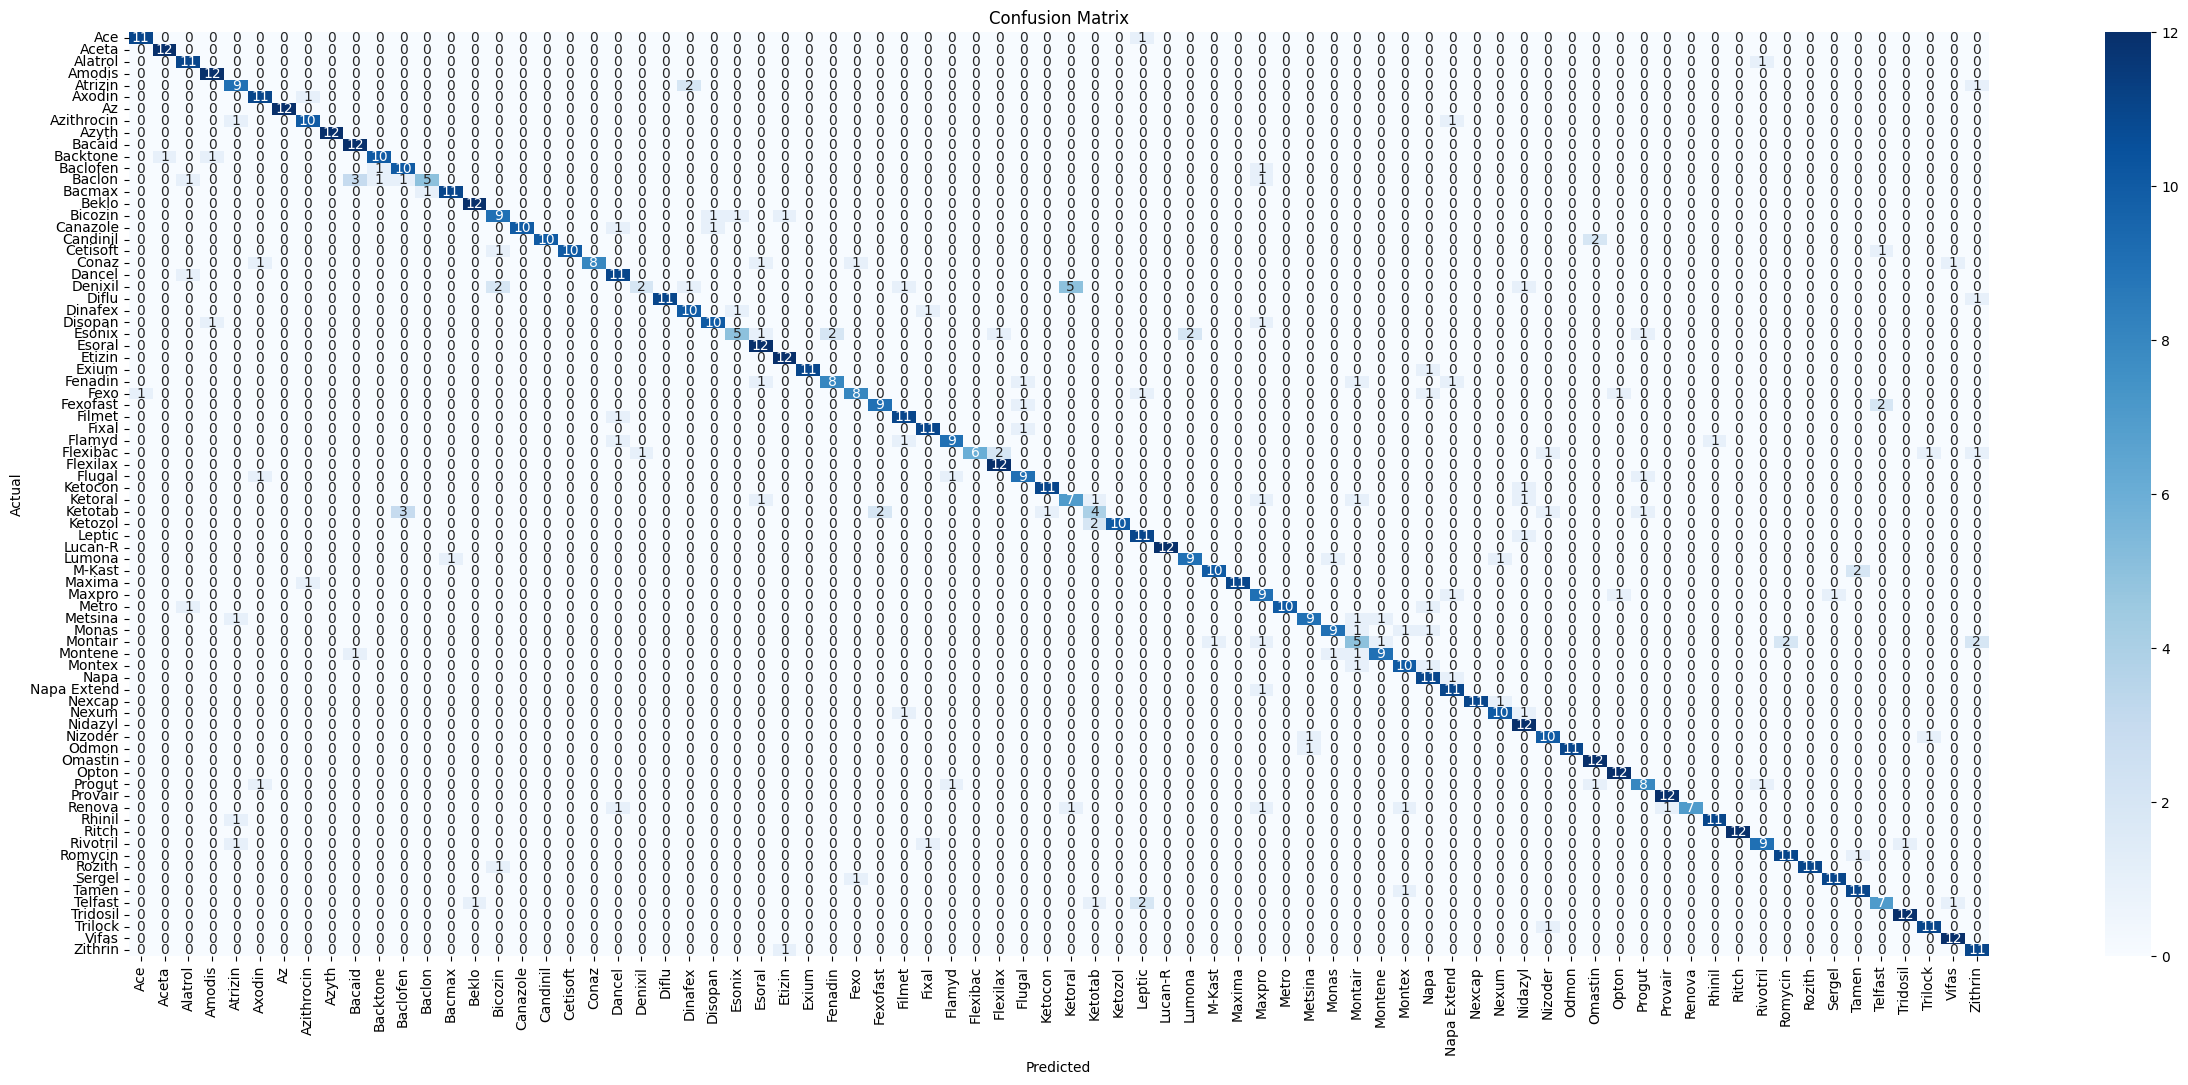

========== FINISHED EXPERIMENT: RESNET50_FINETUNED ==========



In [8]:
# --- Experiment: ResNet50 with Fine-Tuning ---
print("--- Setting up ResNet50 Experiment ---")
model_name = 'resnet50_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final convolutional block (layer4) and the classifier
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

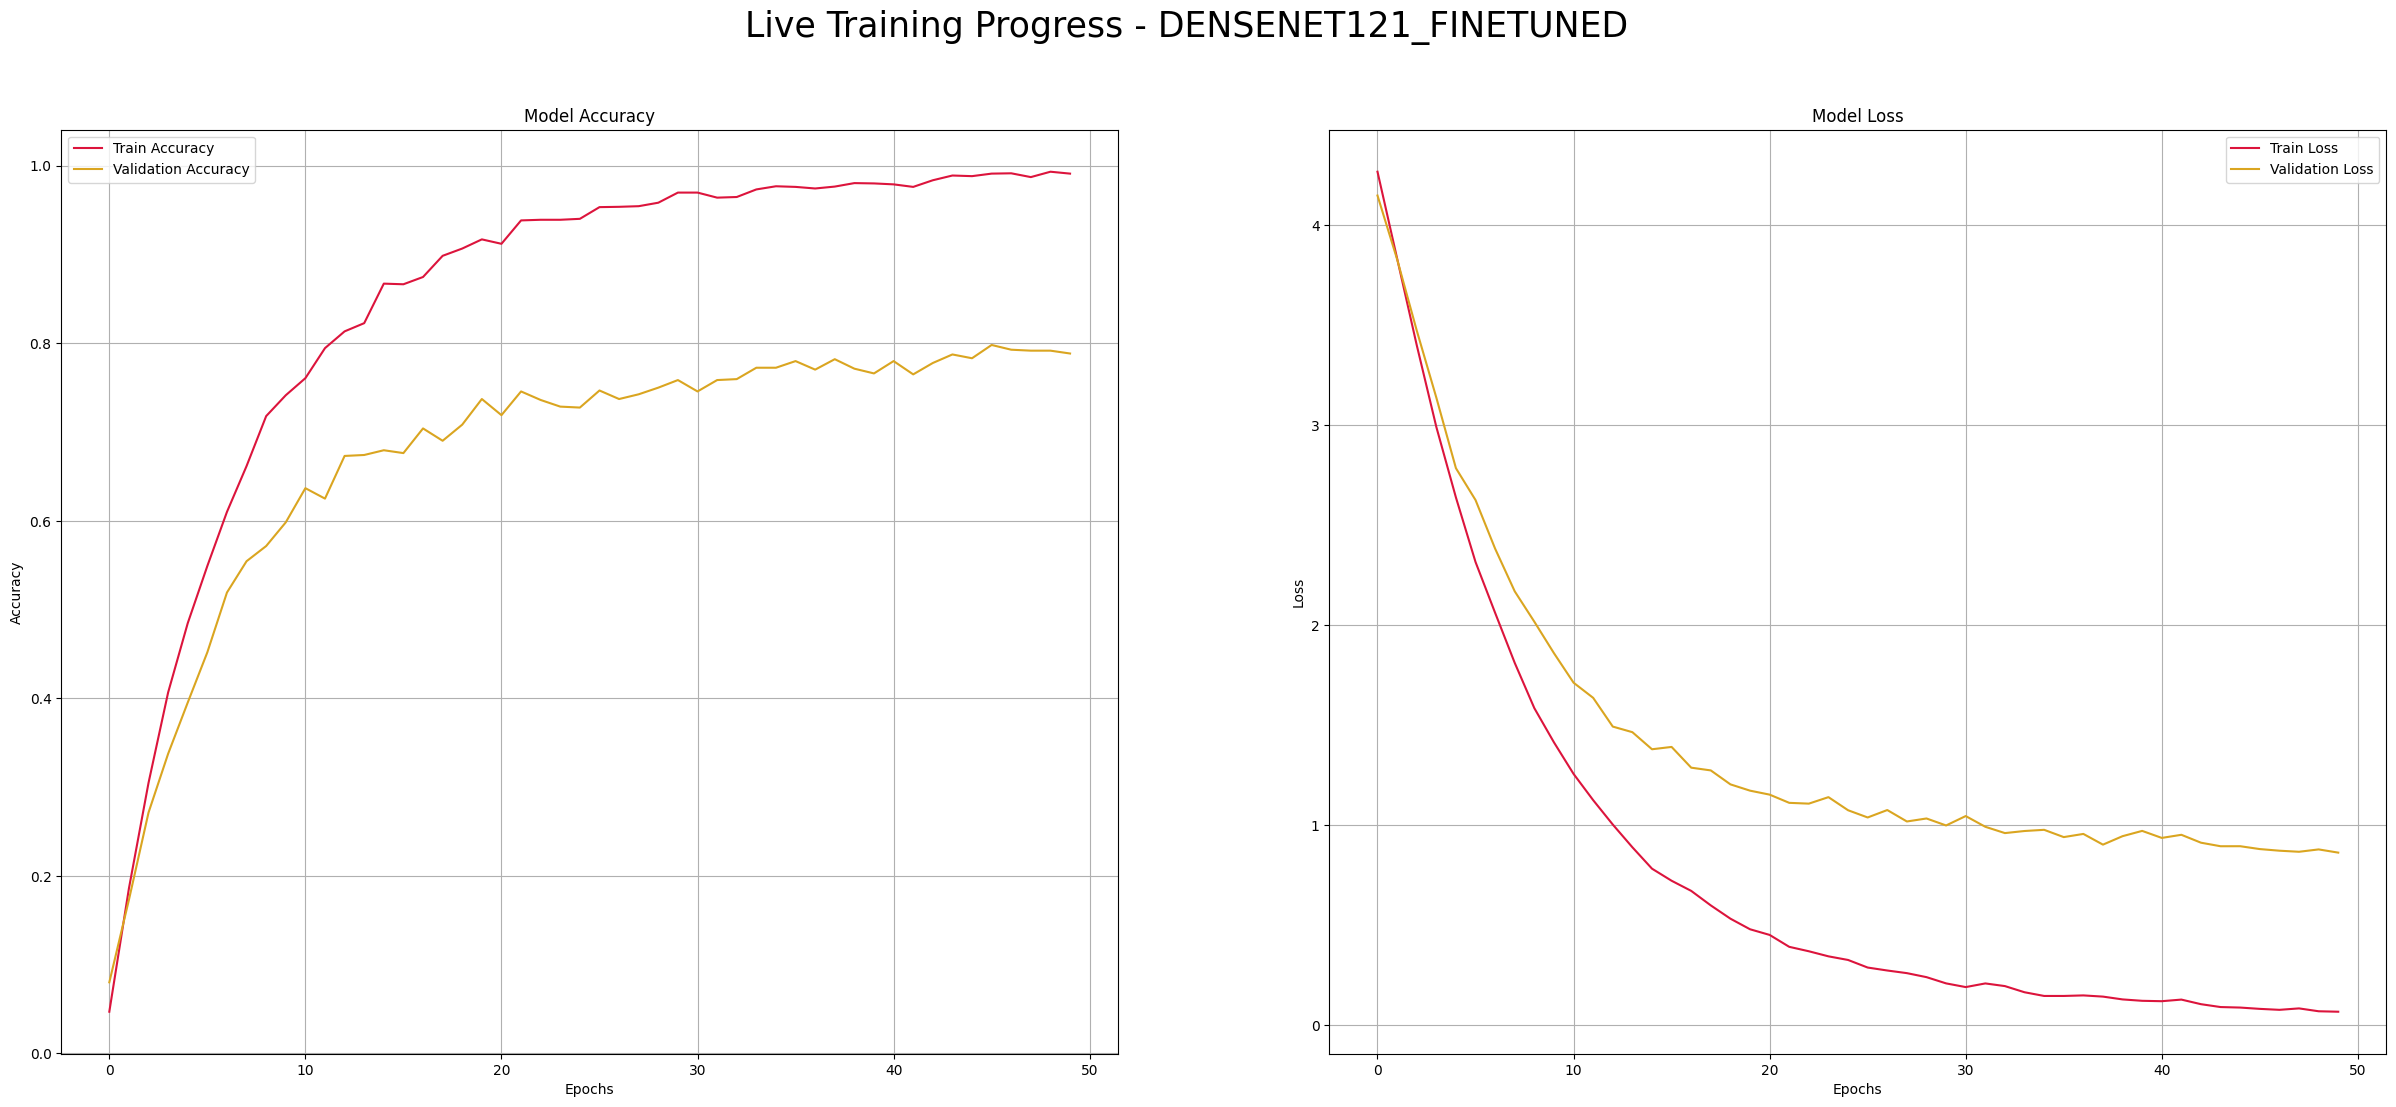

Epoch 50/50 -> Train Acc: 0.9911 | Val Acc: 0.7885

Training complete in 8m 38s
Best val Acc: 0.798077


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       1.00      1.00      1.00        12
       Aceta       0.80      1.00      0.89        12
     Alatrol       0.59      0.83      0.69        12
      Amodis       0.92      0.92      0.92        12
     Atrizin       0.50      0.67      0.57        12
      Axodin       0.85      0.92      0.88        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.83      0.83      0.83        12
       Azyth       0.77      0.83      0.80        12
      Bacaid       0.55      0.92      0.69        12
    Backtone       0.62      0.83      0.71        12
    Baclofen       0.64      0.75      0.69        12
      Baclon       0.00      0.00      0.00        12
      Bacmax       1.00      0.75      0.86        12
       Beklo       0.92      1.00      0.96        12
     Bicozin       0.45      0.75      0.56        12
    Canazole       0.89      0.67      0.76        12
   

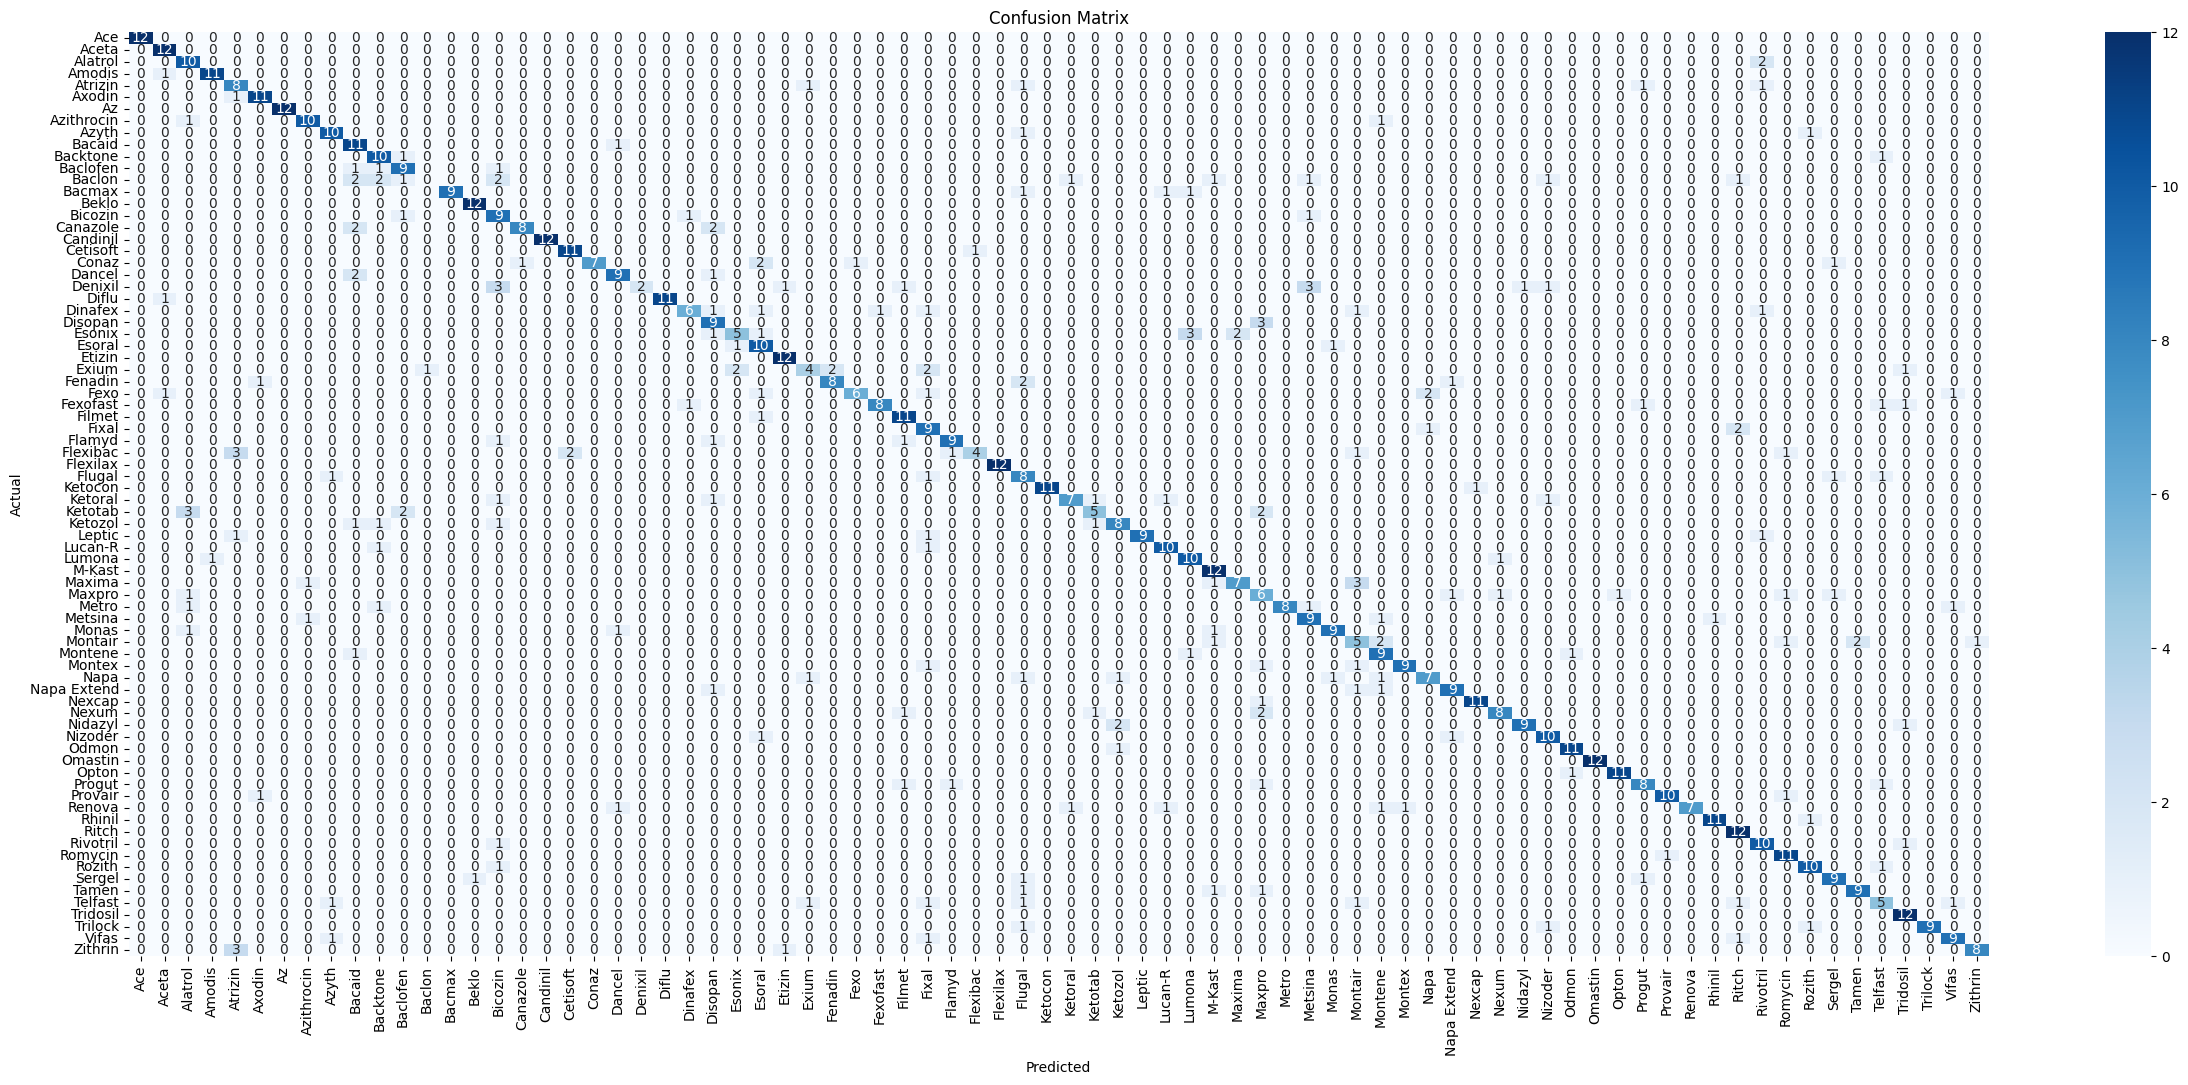

========== FINISHED EXPERIMENT: DENSENET121_FINETUNED ==========



In [9]:
# --- Experiment: DenseNet121 with Fine-Tuning ---
print("\n--- Setting up DenseNet121 Experiment ---")
model_name = 'densenet121_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.densenet121(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last dense block, the final norm layer, and the classifier
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

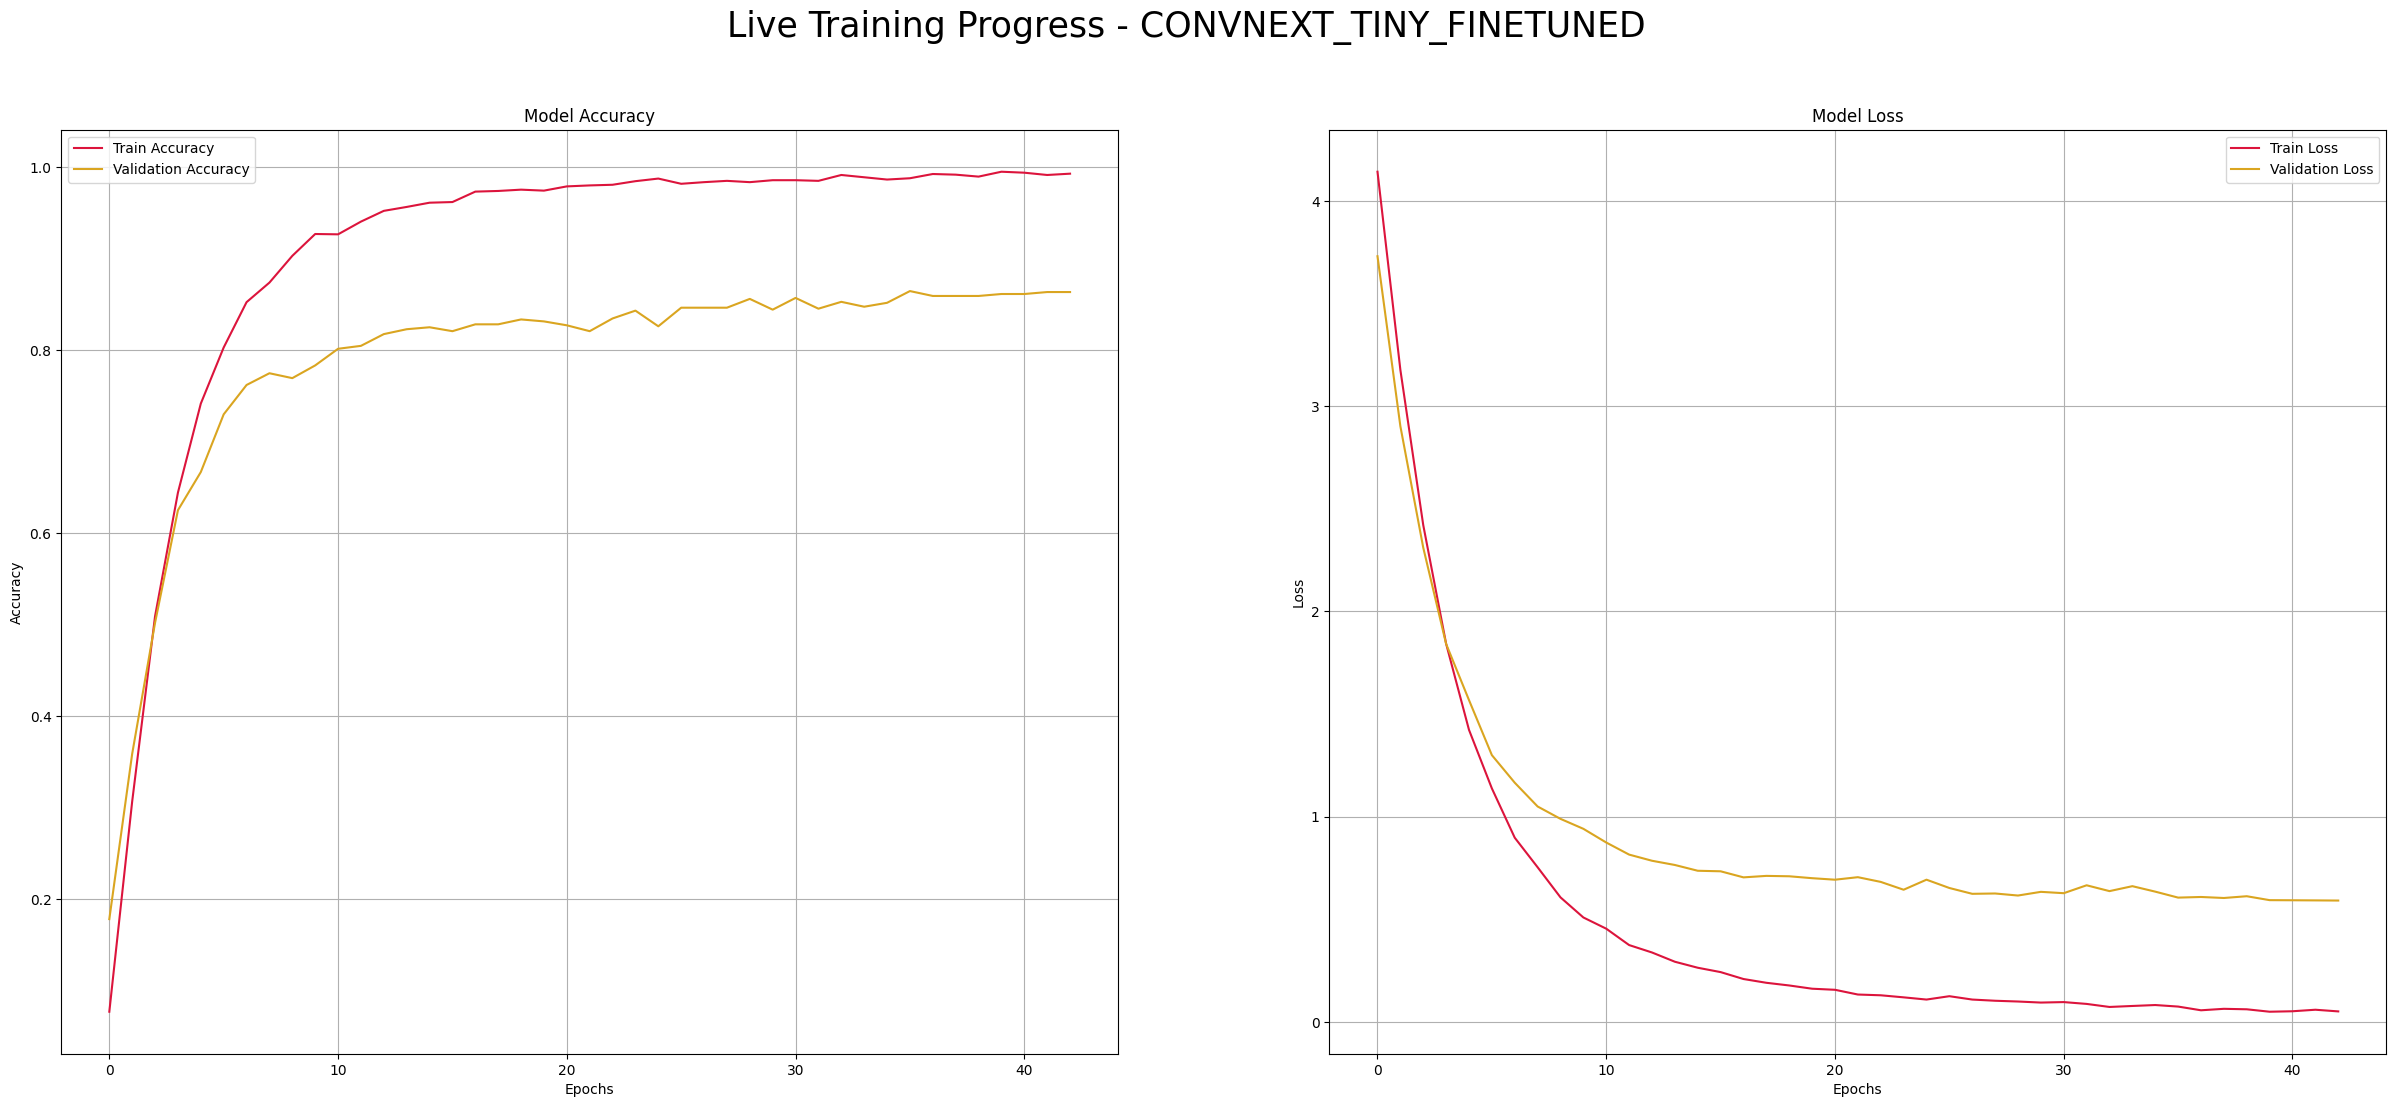

Epoch 43/50 -> Train Acc: 0.9925 | Val Acc: 0.8632
Early stopping triggered after 7 epochs with no improvement.

Training complete in 11m 46s
Best val Acc: 0.864316


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       1.00      1.00      1.00        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.80      1.00      0.89        12
      Amodis       1.00      1.00      1.00        12
     Atrizin       0.78      0.58      0.67        12
      Axodin       0.85      0.92      0.88        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.82      0.75      0.78        12
       Azyth       0.73      0.92      0.81        12
      Bacaid       0.75      1.00      0.86        12
    Backtone       0.85      0.92      0.88        12
    Baclofen       0.70      0.58      0.64        12
      Baclon       1.00      0.25      0.40        12
      Bacmax       1.00      0.92      0.96        12
       Beklo       0.80      1.00      0.89        12
     Bicozin       0.79      0.92      0.85        12
    Canazole       0.80      1.00      0.89        12
   

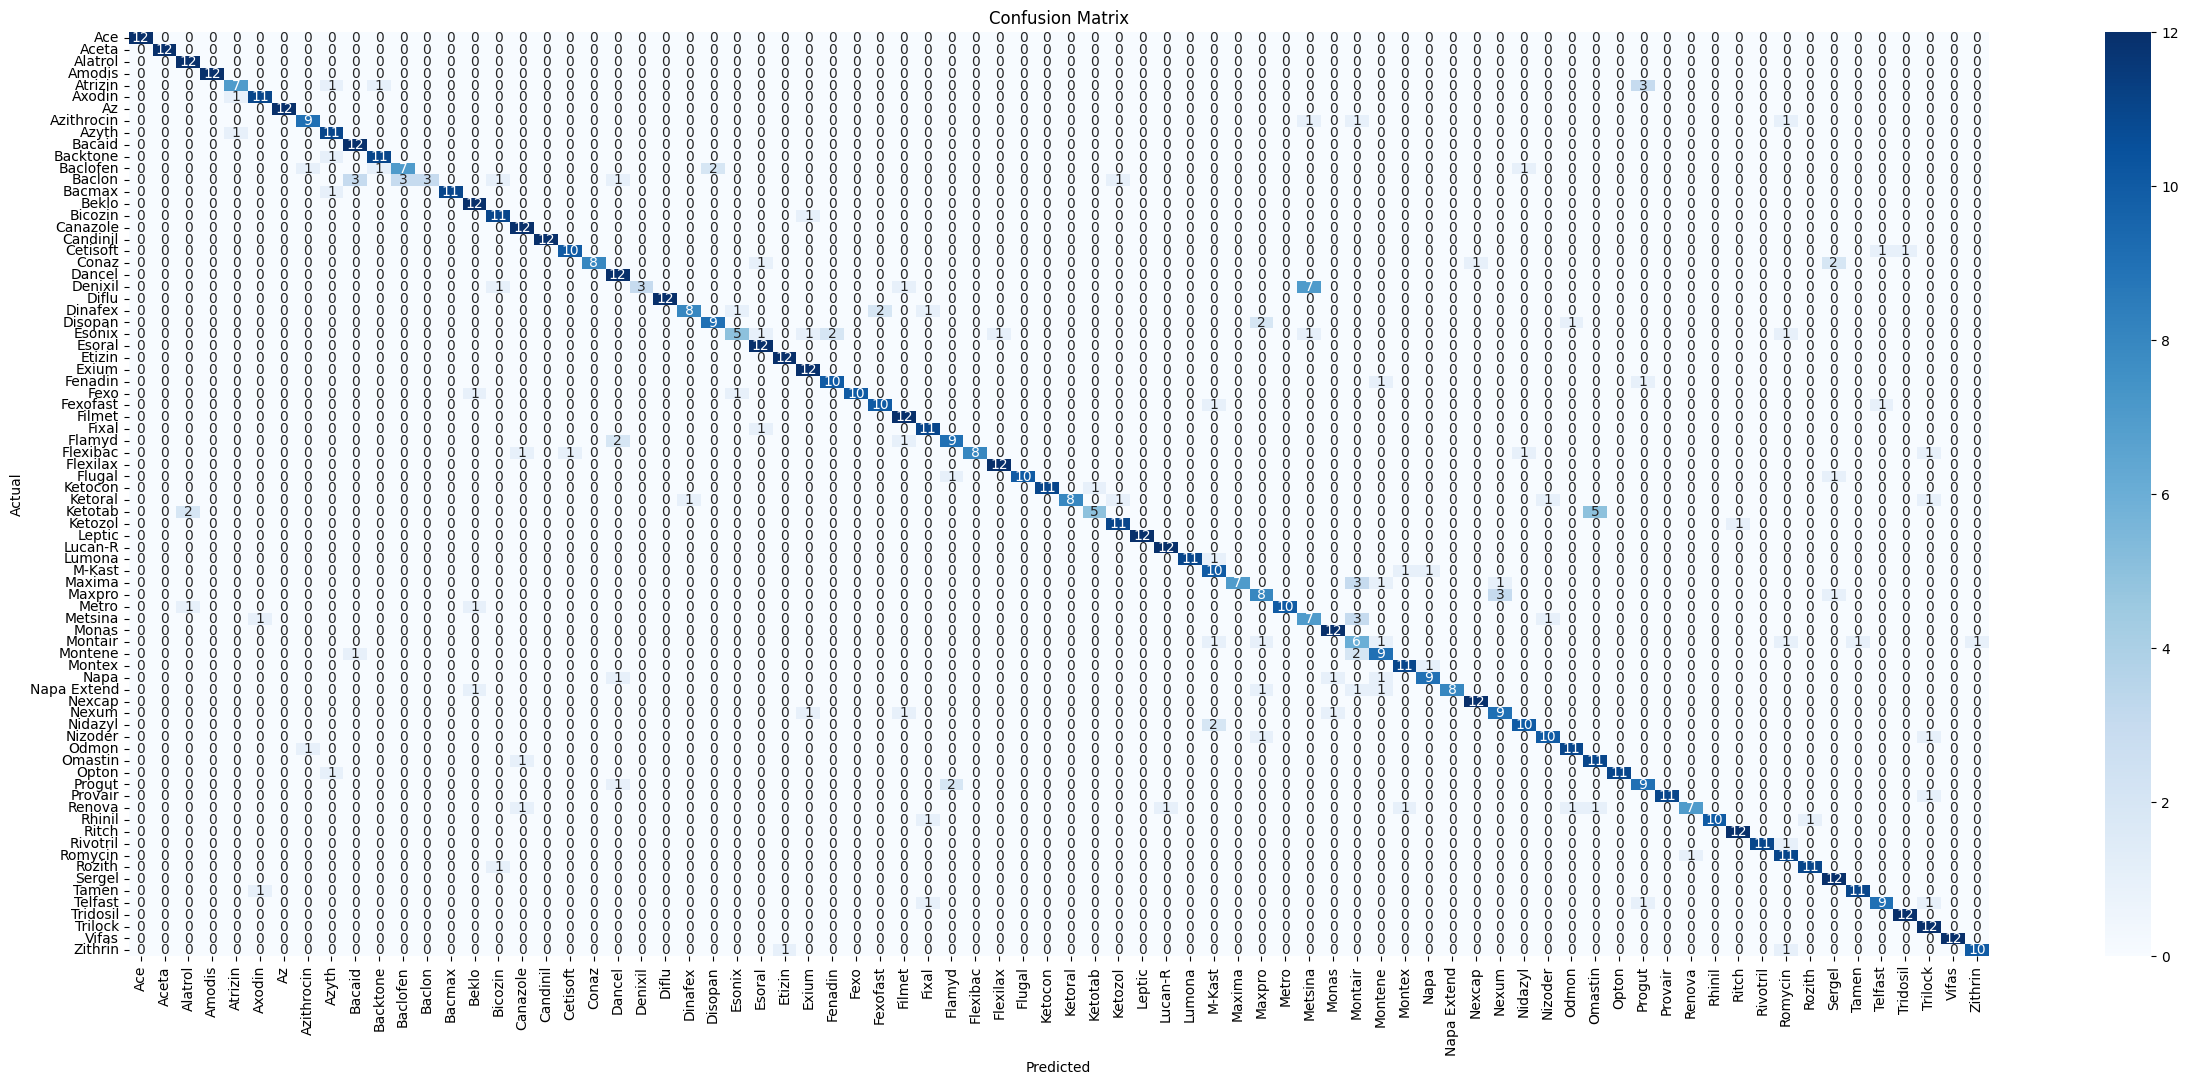

========== FINISHED EXPERIMENT: CONVNEXT_TINY_FINETUNED ==========



In [10]:
# --- Experiment: ConvNeXt-Tiny with Fine-Tuning ---
print("\n--- Setting up ConvNeXt-Tiny Experiment ---")
model_name = 'convnext_tiny_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.convnext_tiny(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last feature block and the classifier
for param in model.features[7].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

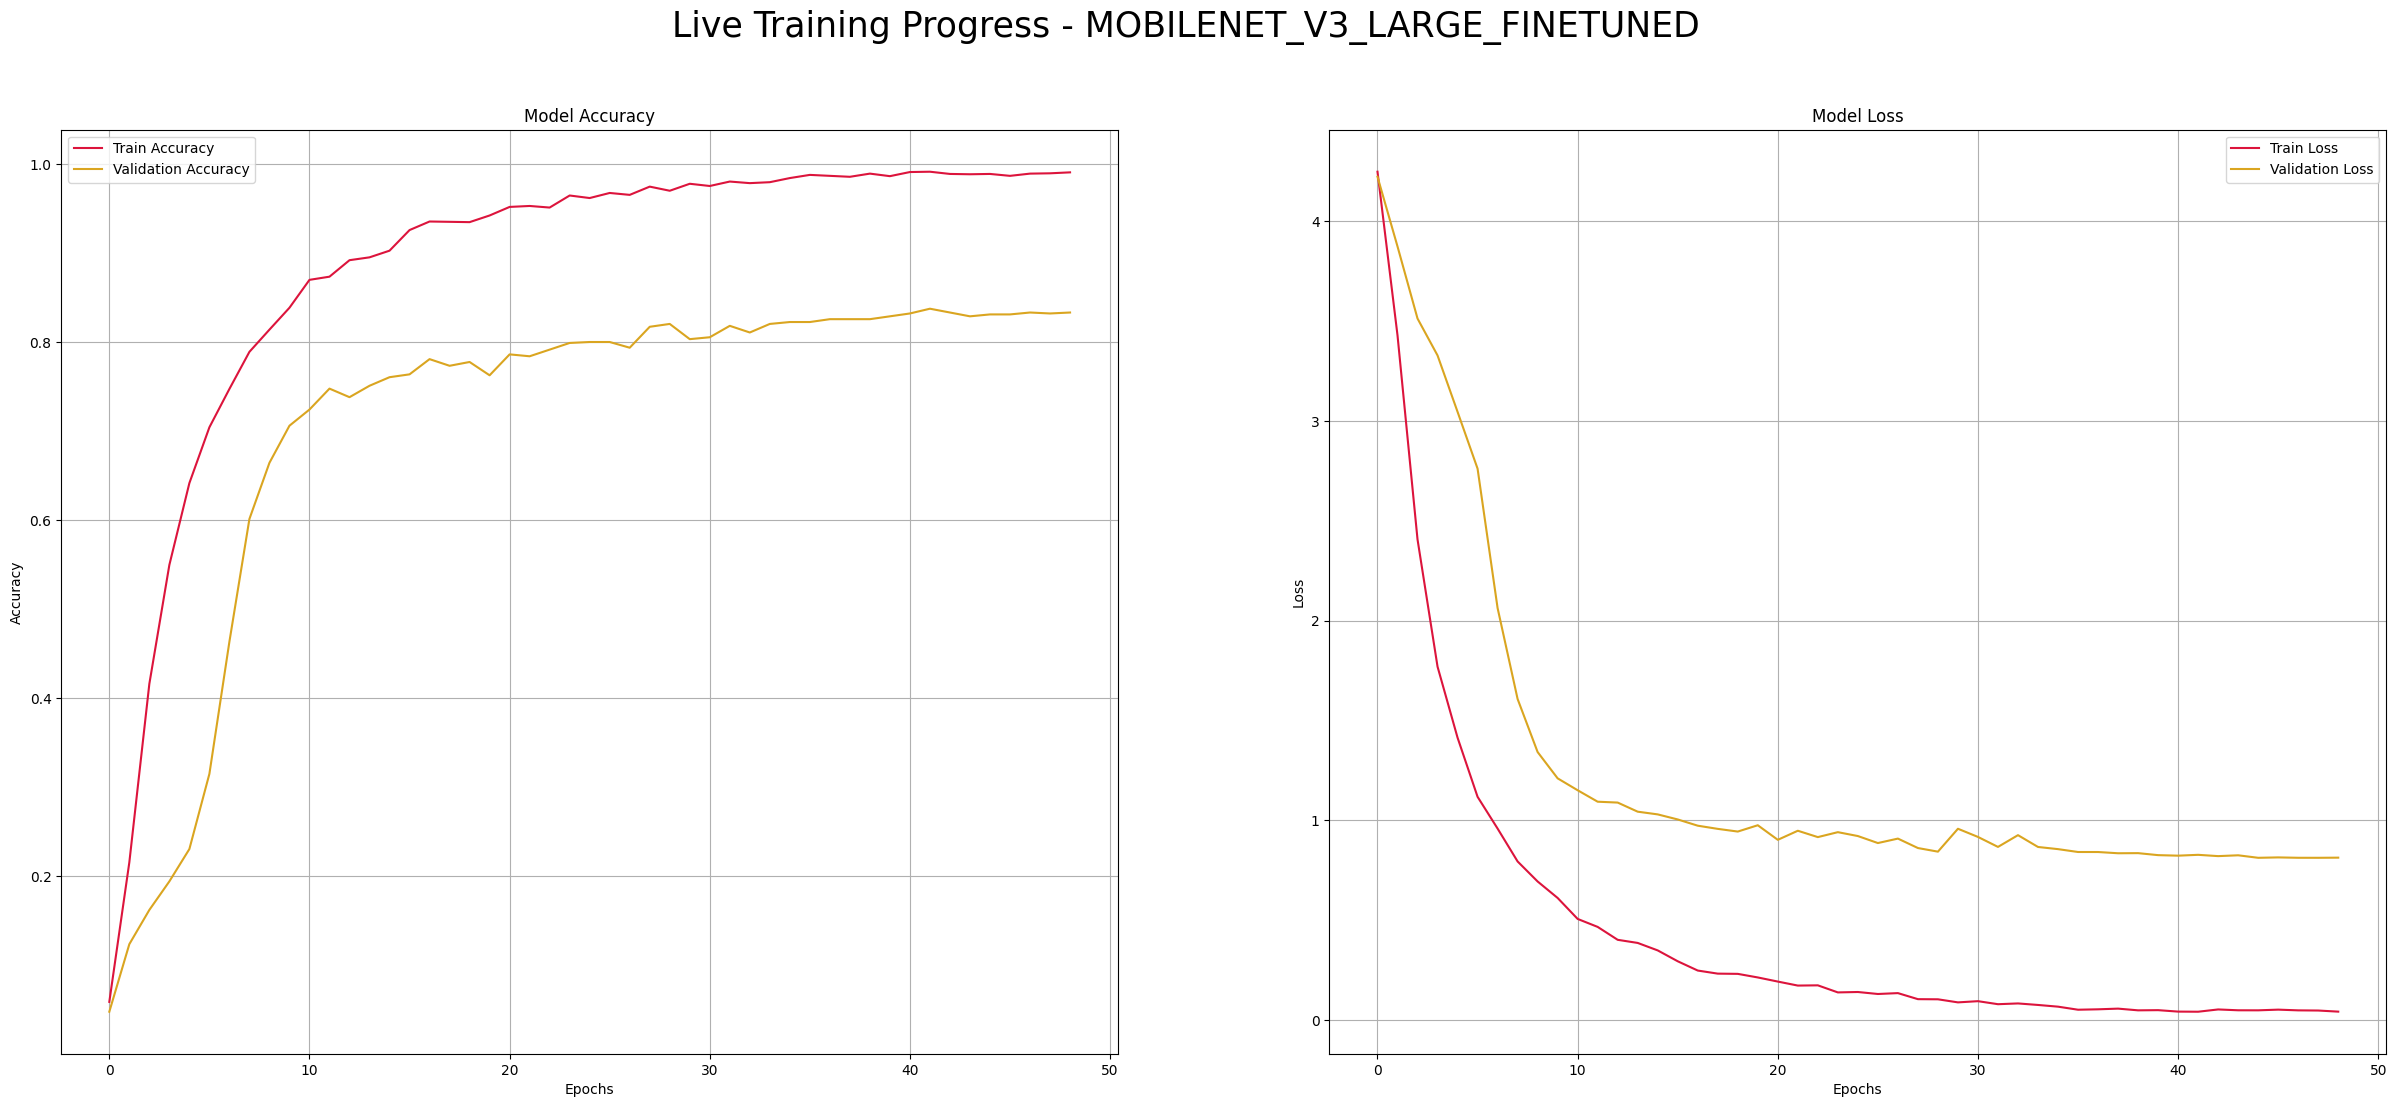

Epoch 49/50 -> Train Acc: 0.9907 | Val Acc: 0.8333
Early stopping triggered after 7 epochs with no improvement.

Training complete in 5m 33s
Best val Acc: 0.837607


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       0.92      1.00      0.96        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.92      1.00      0.96        12
      Amodis       0.92      1.00      0.96        12
     Atrizin       0.60      0.75      0.67        12
      Axodin       0.86      1.00      0.92        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.71      0.83      0.77        12
       Azyth       1.00      0.83      0.91        12
      Bacaid       0.92      0.92      0.92        12
    Backtone       0.79      0.92      0.85        12
    Baclofen       0.83      0.83      0.83        12
      Baclon       0.50      0.17      0.25        12
      Bacmax       0.75      0.75      0.75        12
       Beklo       0.86      1.00      0.92        12
     Bicozin       0.77      0.83      0.80        12
    Canazole       0.53      0.83      0.65        12
   

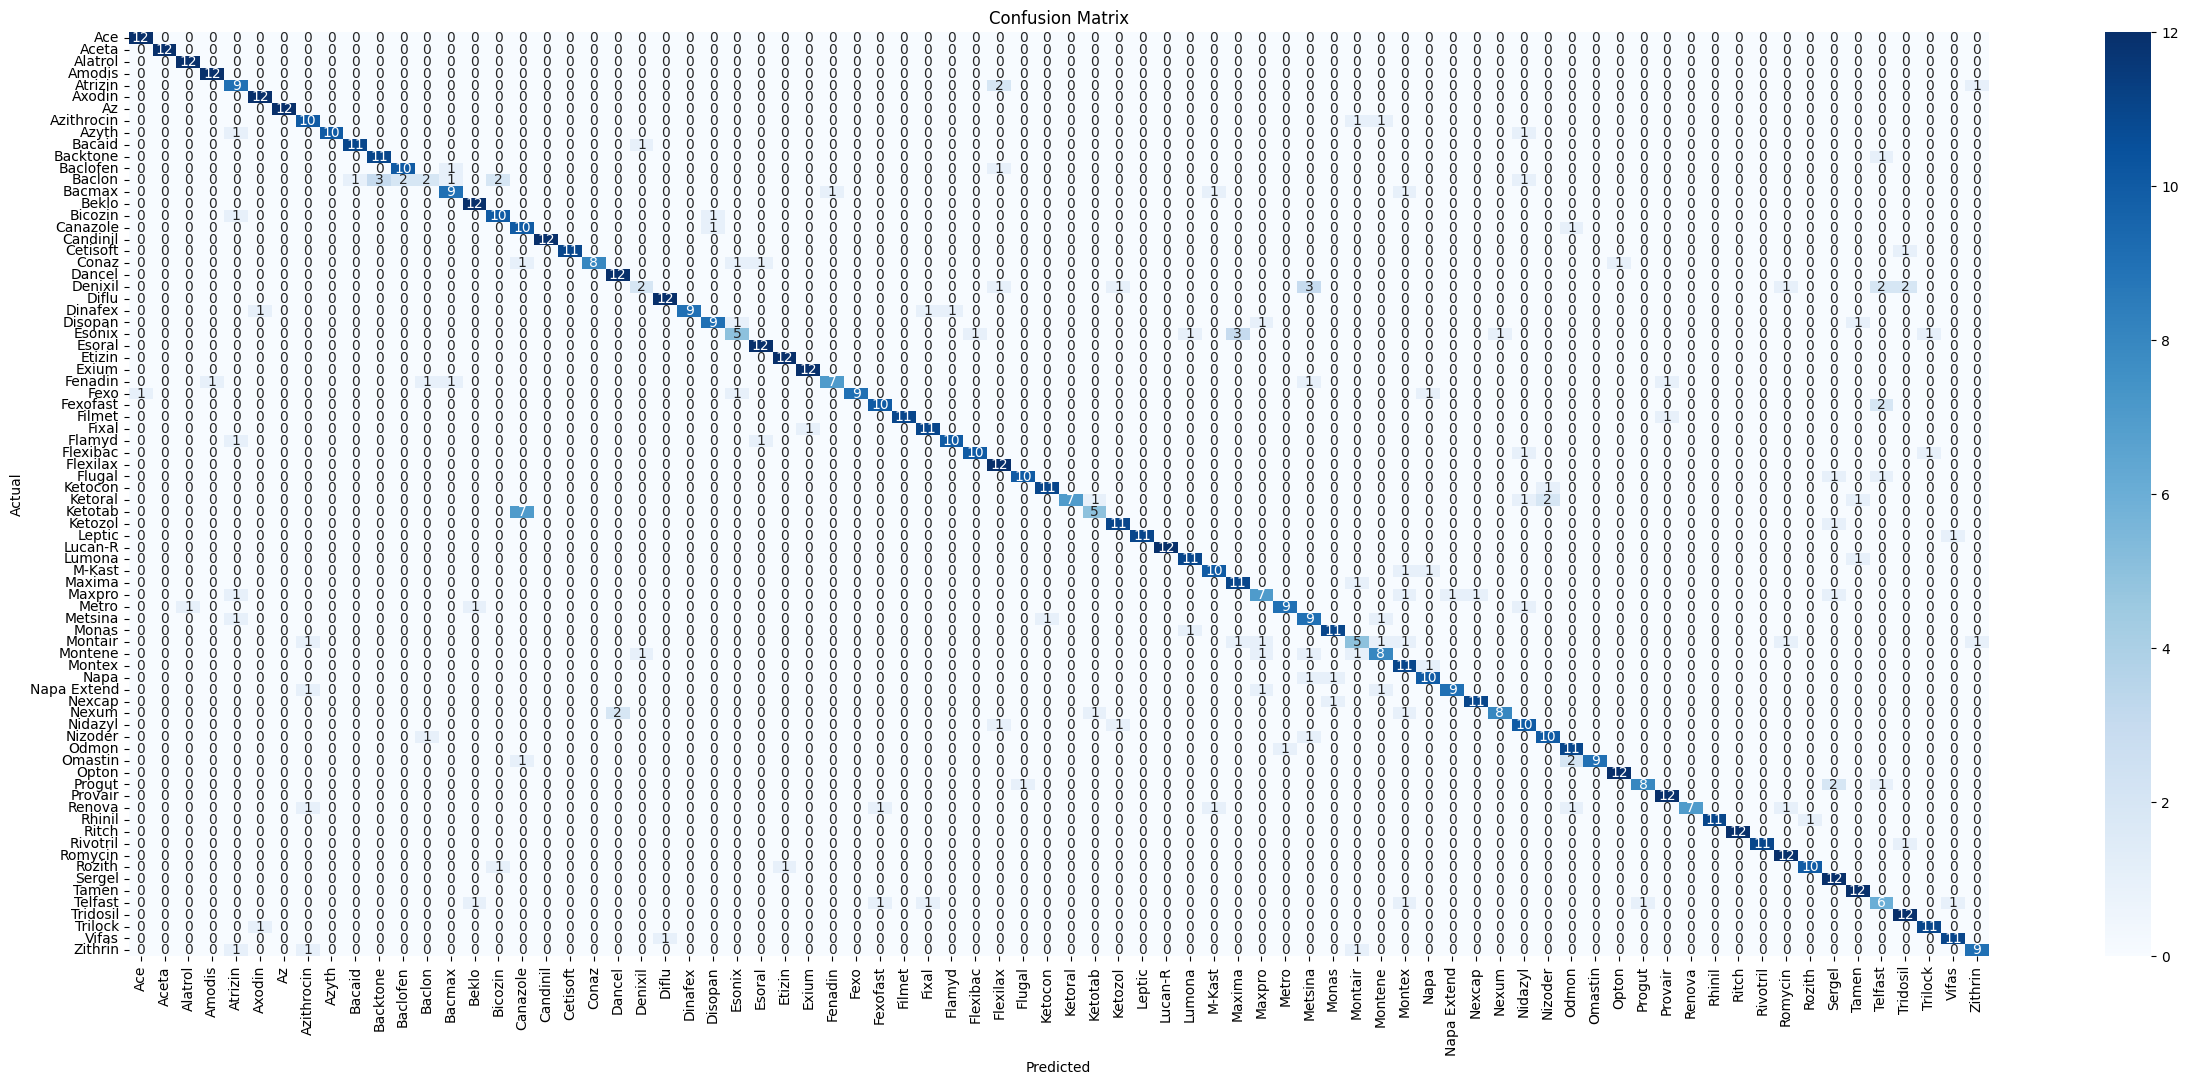

========== FINISHED EXPERIMENT: MOBILENET_V3_LARGE_FINETUNED ==========



In [11]:
# --- Experiment: MobileNetV3-Large with Fine-Tuning ---
print("\n--- Setting up MobileNetV3-Large Experiment ---")
model_name = 'mobilenet_v3_large_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.mobilenet_v3_large(weights='IMAGENET1K_V2')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the later feature blocks and the classifier
for param in model.features[13:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

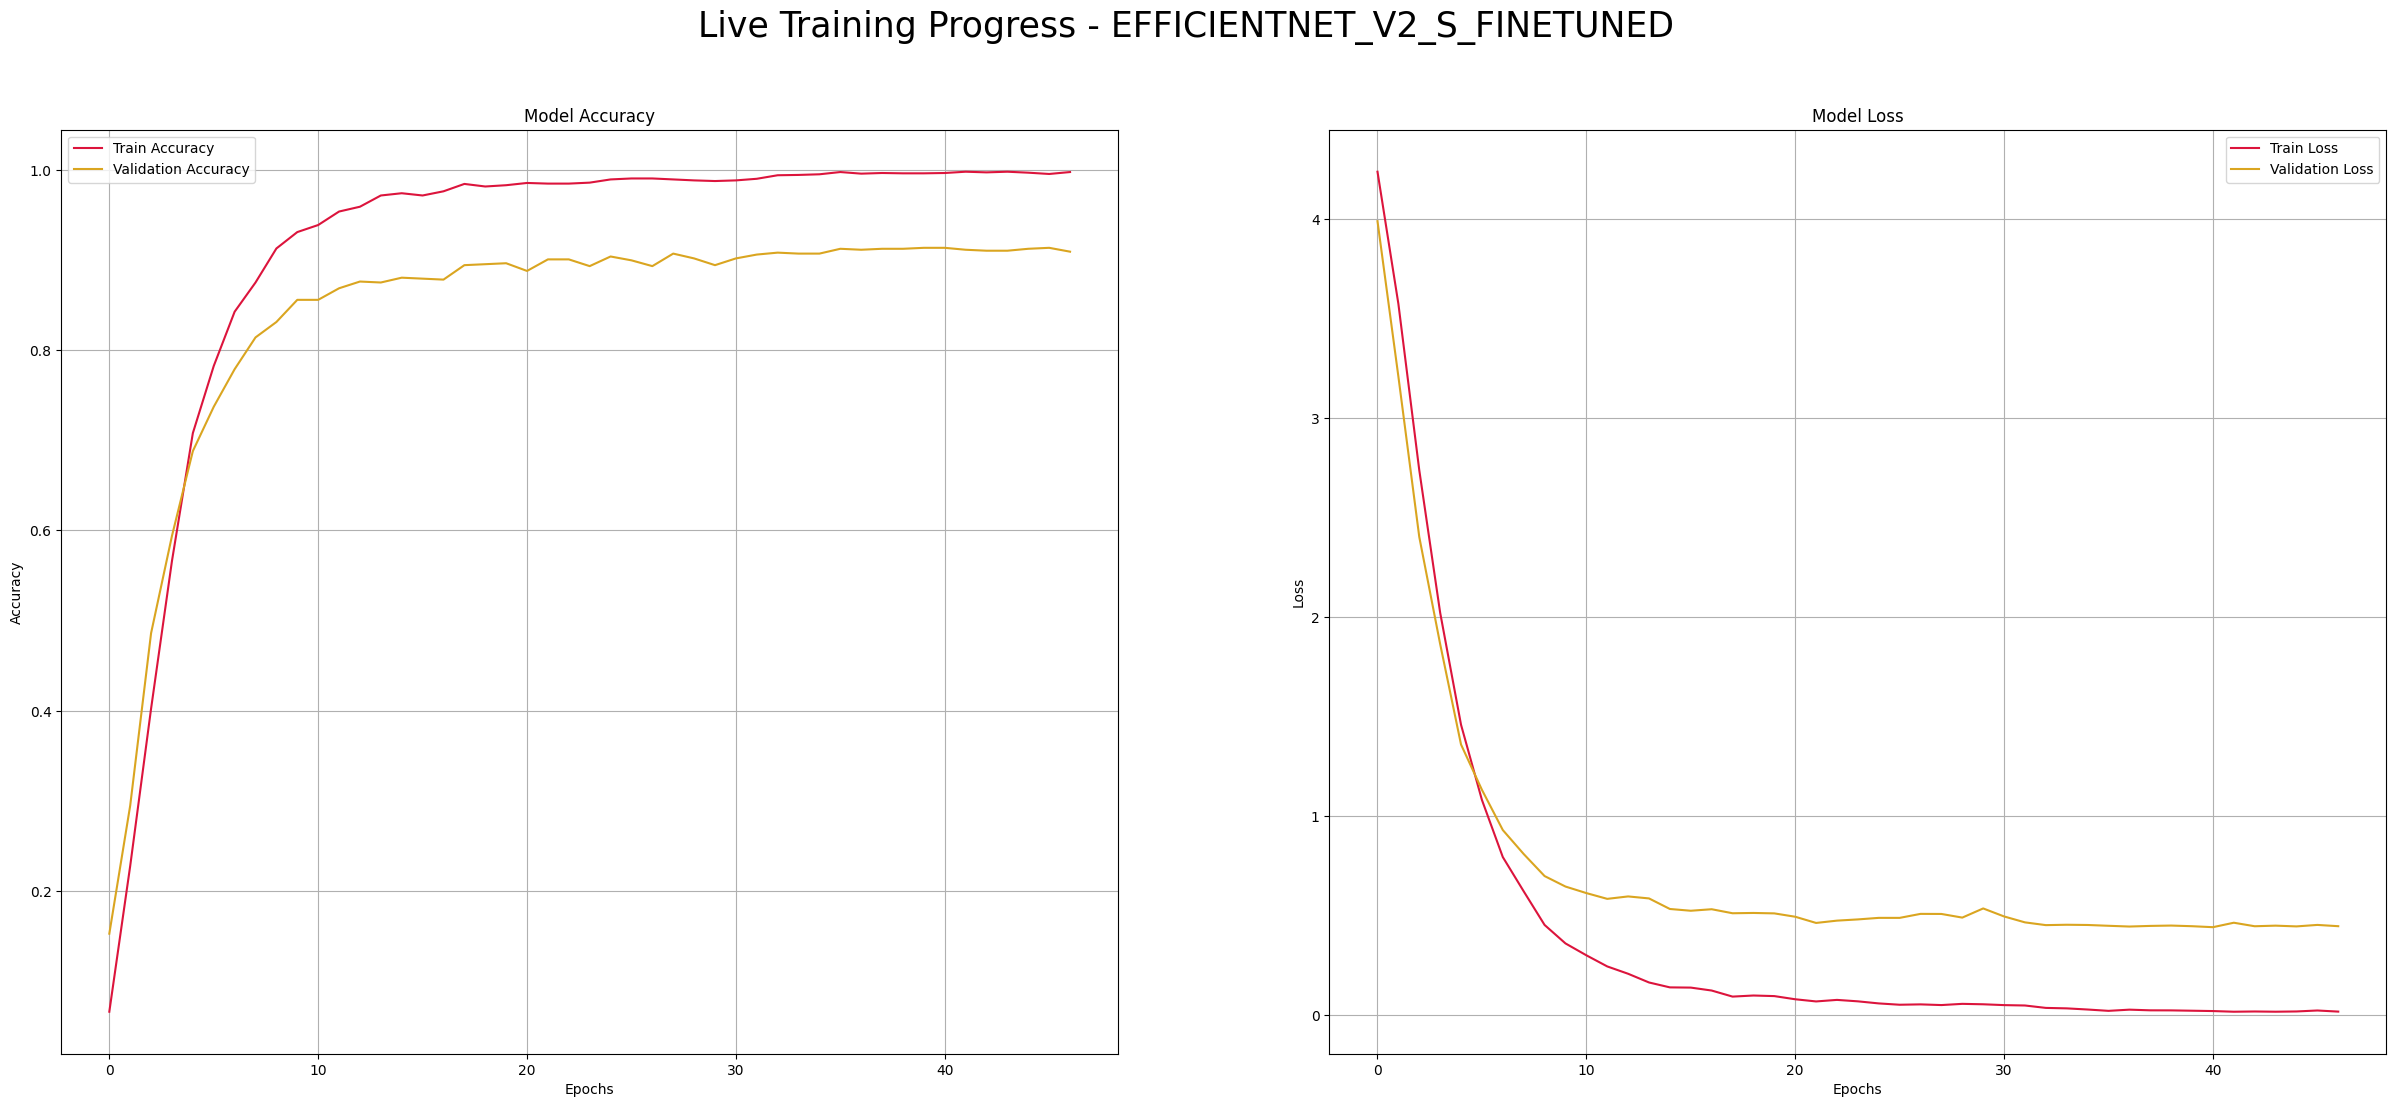

Epoch 47/50 -> Train Acc: 0.9975 | Val Acc: 0.9092
Early stopping triggered after 7 epochs with no improvement.

Training complete in 24m 47s
Best val Acc: 0.913462


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       0.86      1.00      0.92        12
       Aceta       0.92      1.00      0.96        12
     Alatrol       0.86      1.00      0.92        12
      Amodis       1.00      1.00      1.00        12
     Atrizin       0.82      0.75      0.78        12
      Axodin       1.00      1.00      1.00        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.85      0.92      0.88        12
       Azyth       1.00      0.92      0.96        12
      Bacaid       0.71      1.00      0.83        12
    Backtone       0.92      0.92      0.92        12
    Baclofen       0.91      0.83      0.87        12
      Baclon       1.00      0.42      0.59        12
      Bacmax       0.85      0.92      0.88        12
       Beklo       0.86      1.00      0.92        12
     Bicozin       0.86      1.00      0.92        12
    Canazole       0.92      1.00      0.96        12
   

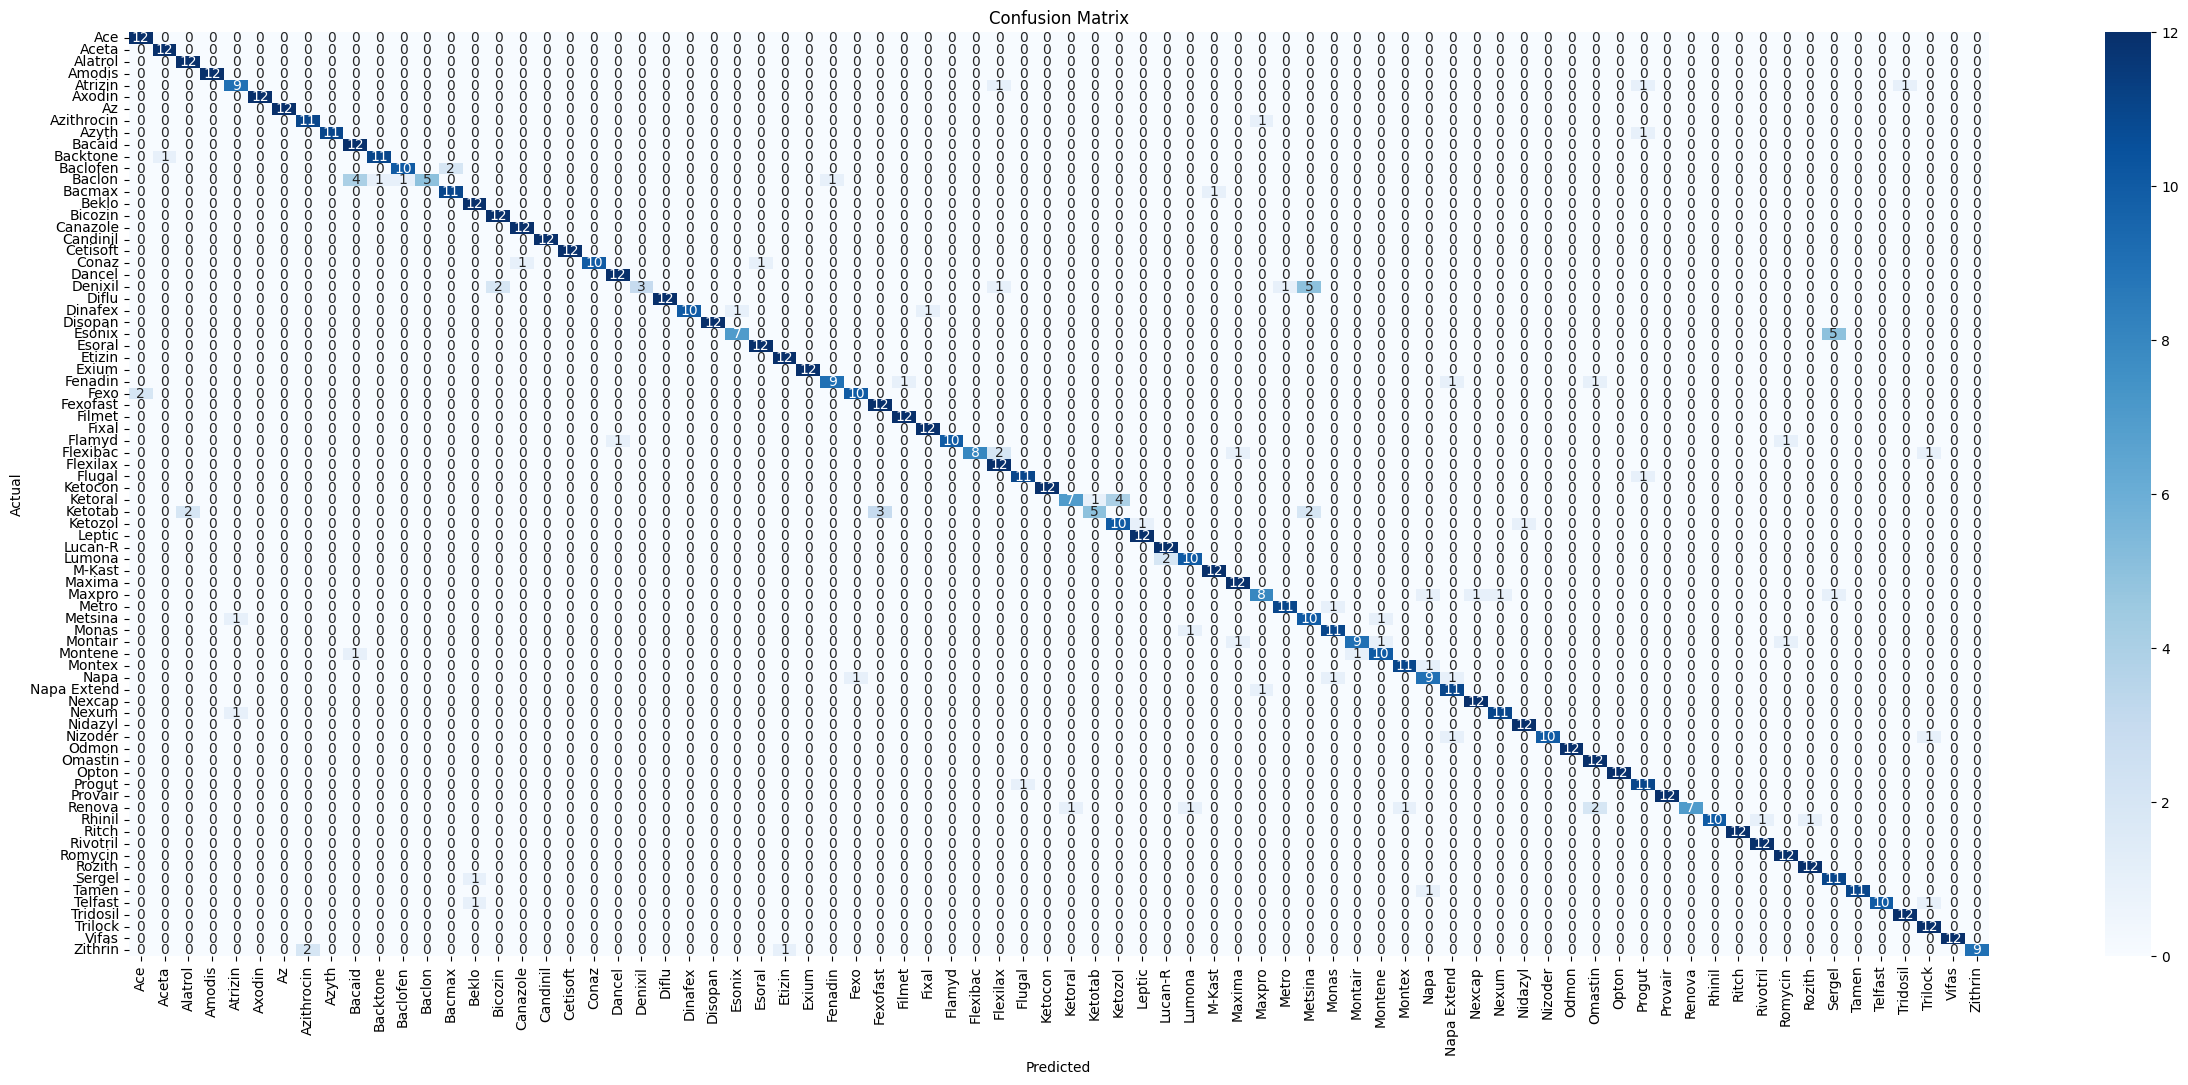

========== FINISHED EXPERIMENT: EFFICIENTNET_V2_S_FINETUNED ==========



In [12]:
# --- Experiment: EfficientNetV2-S with Fine-Tuning ---
print("\n--- Setting up EfficientNetV2-S Experiment ---")
model_name = 'efficientnet_v2_s_finetuned'
image_size = 384 # Use the recommended image size for this model

# Get data loaders for this experiment's image size
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last two feature blocks and the classifier
for param in model.features[6:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

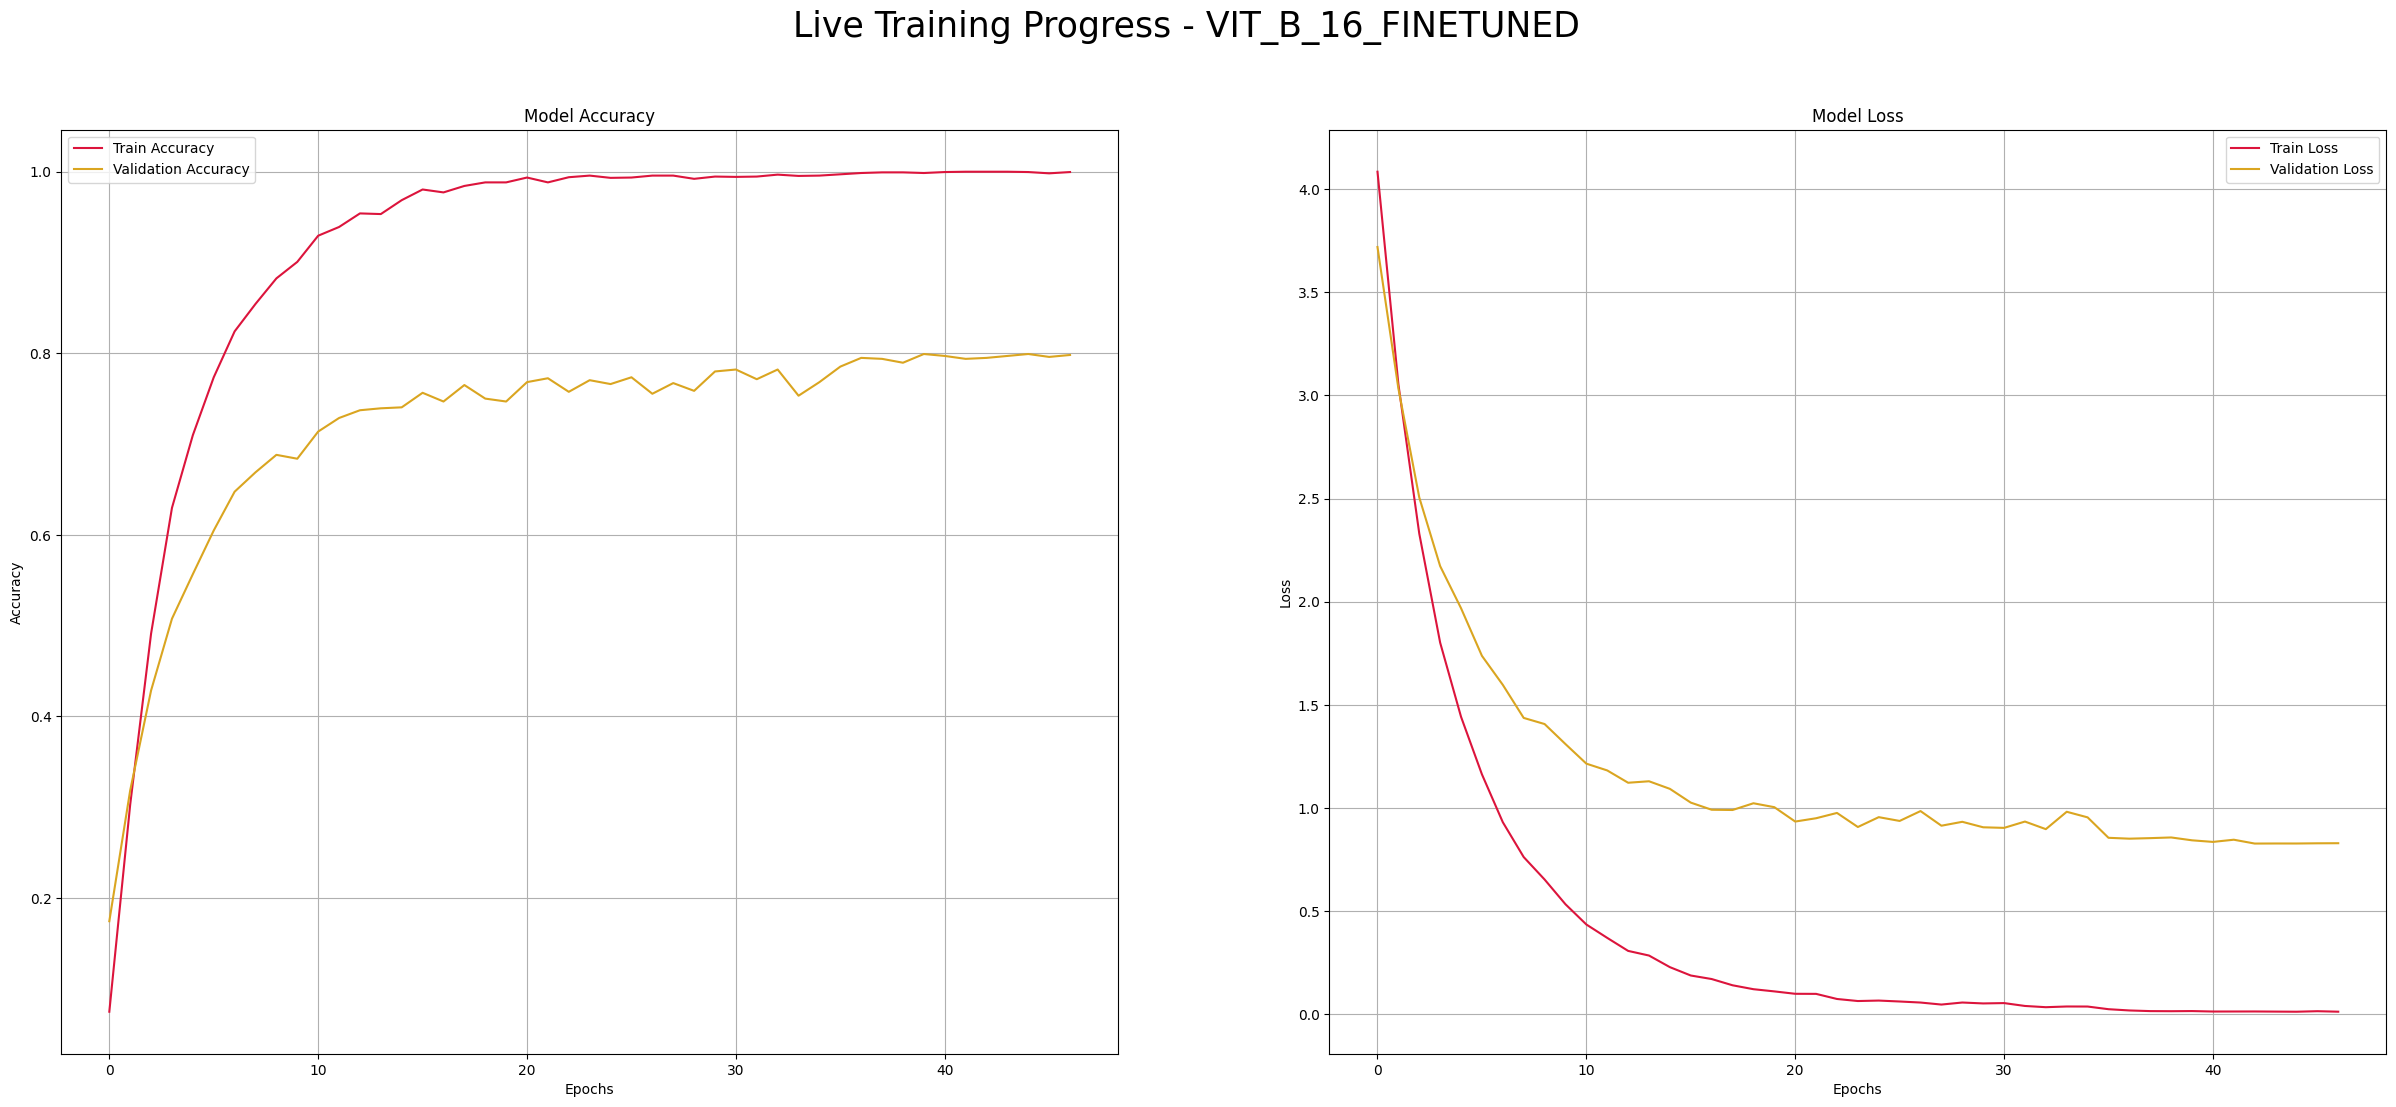

Epoch 47/50 -> Train Acc: 0.9996 | Val Acc: 0.7981
Early stopping triggered after 7 epochs with no improvement.

Training complete in 23m 51s
Best val Acc: 0.799145


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       0.92      0.92      0.92        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.59      0.83      0.69        12
      Amodis       1.00      0.92      0.96        12
     Atrizin       0.73      0.67      0.70        12
      Axodin       0.92      0.92      0.92        12
          Az       1.00      0.92      0.96        12
  Azithrocin       0.85      0.92      0.88        12
       Azyth       0.75      0.75      0.75        12
      Bacaid       0.71      1.00      0.83        12
    Backtone       0.73      0.92      0.81        12
    Baclofen       0.86      0.50      0.63        12
      Baclon       0.60      0.25      0.35        12
      Bacmax       0.83      0.83      0.83        12
       Beklo       0.61      0.92      0.73        12
     Bicozin       0.91      0.83      0.87        12
    Canazole       0.80      0.67      0.73        12
   

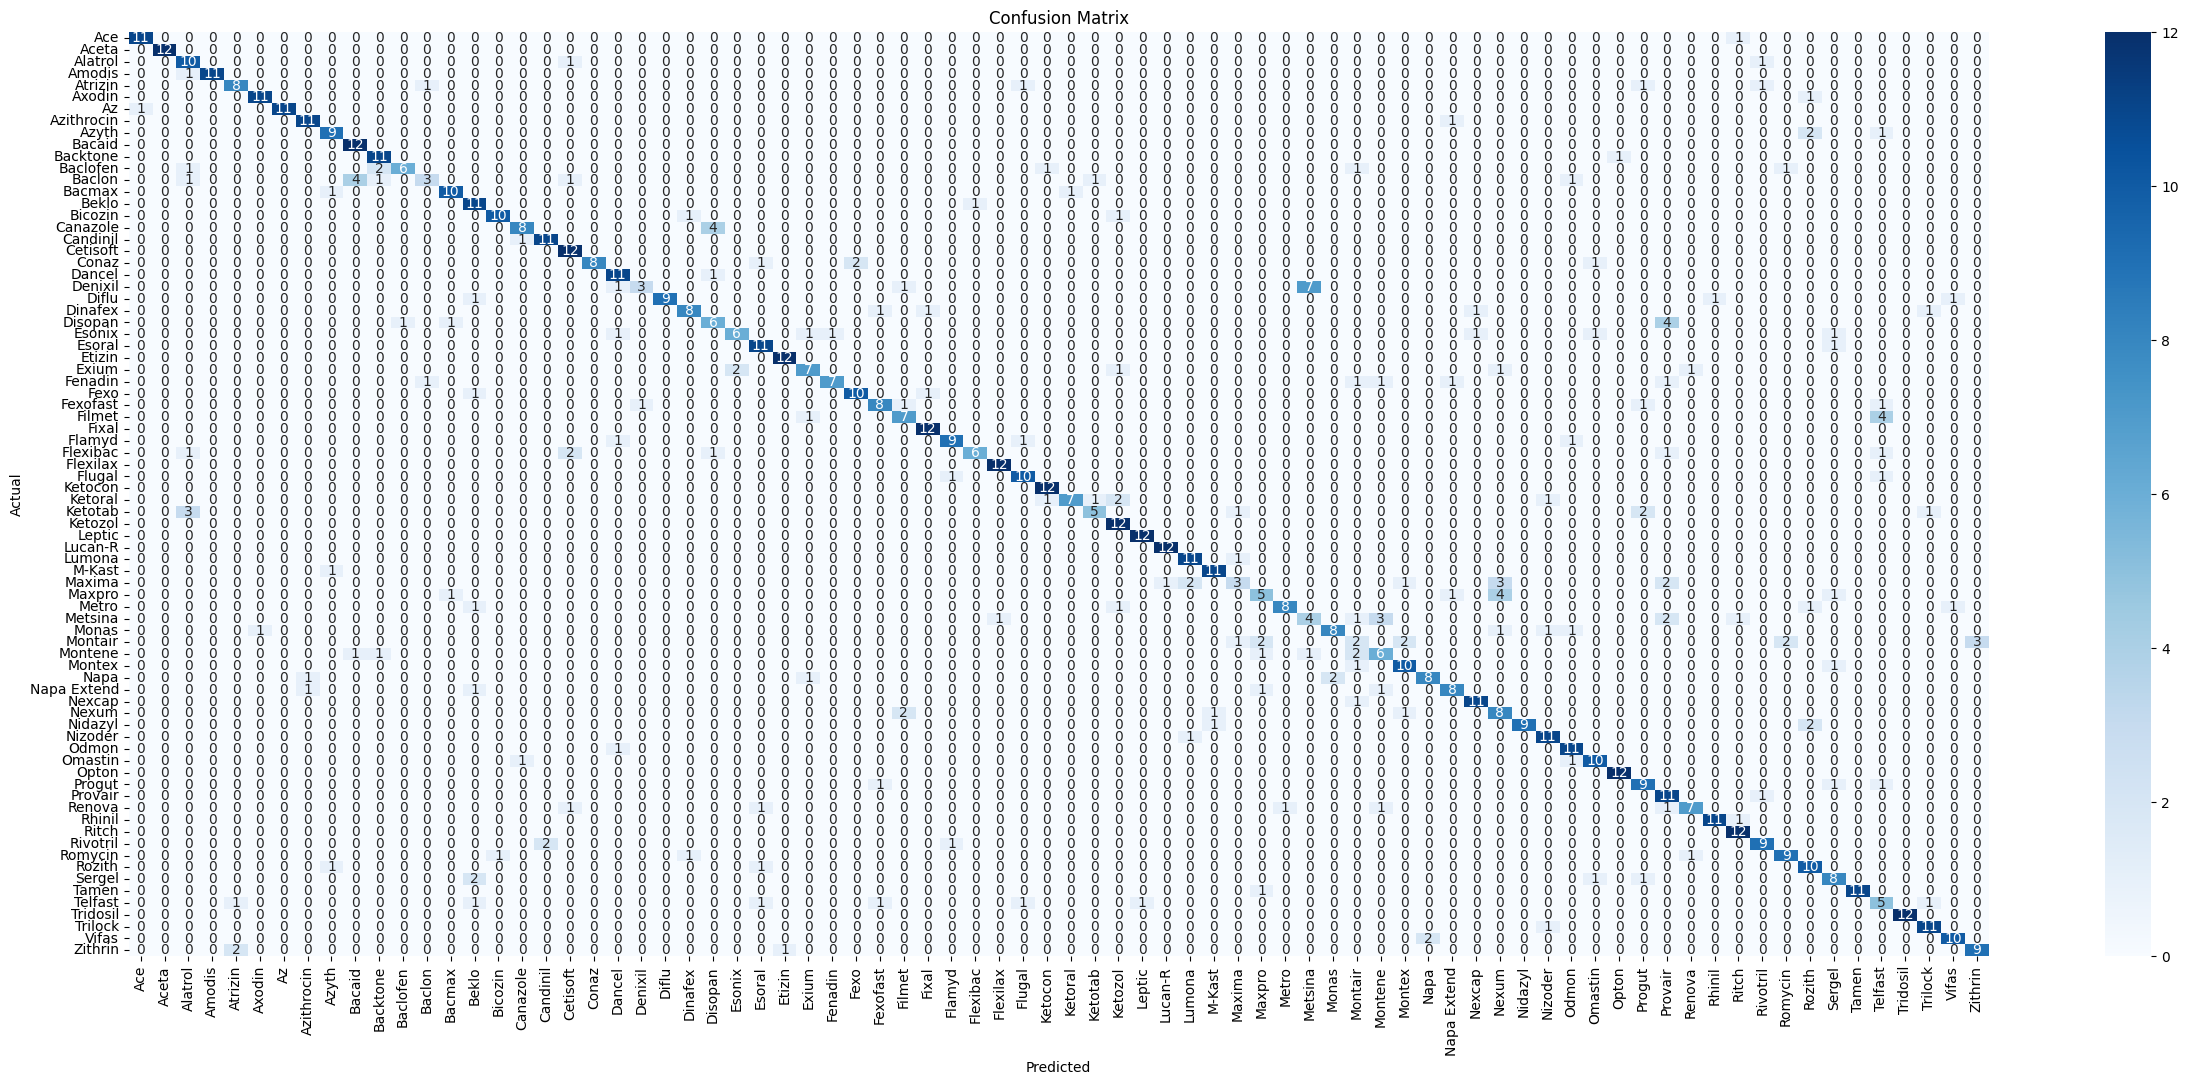

========== FINISHED EXPERIMENT: VIT_B_16_FINETUNED ==========



In [13]:
# --- Experiment: Vision Transformer (ViT-B/16) with Fine-Tuning ---
print("\n--- Setting up Vision Transformer Experiment ---")
model_name = 'vit_b_16_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.vit_b_16(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the final encoder block and the classifier head
for param in model.encoder.layers.encoder_layer_11.parameters():
    param.requires_grad = True
for param in model.heads.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

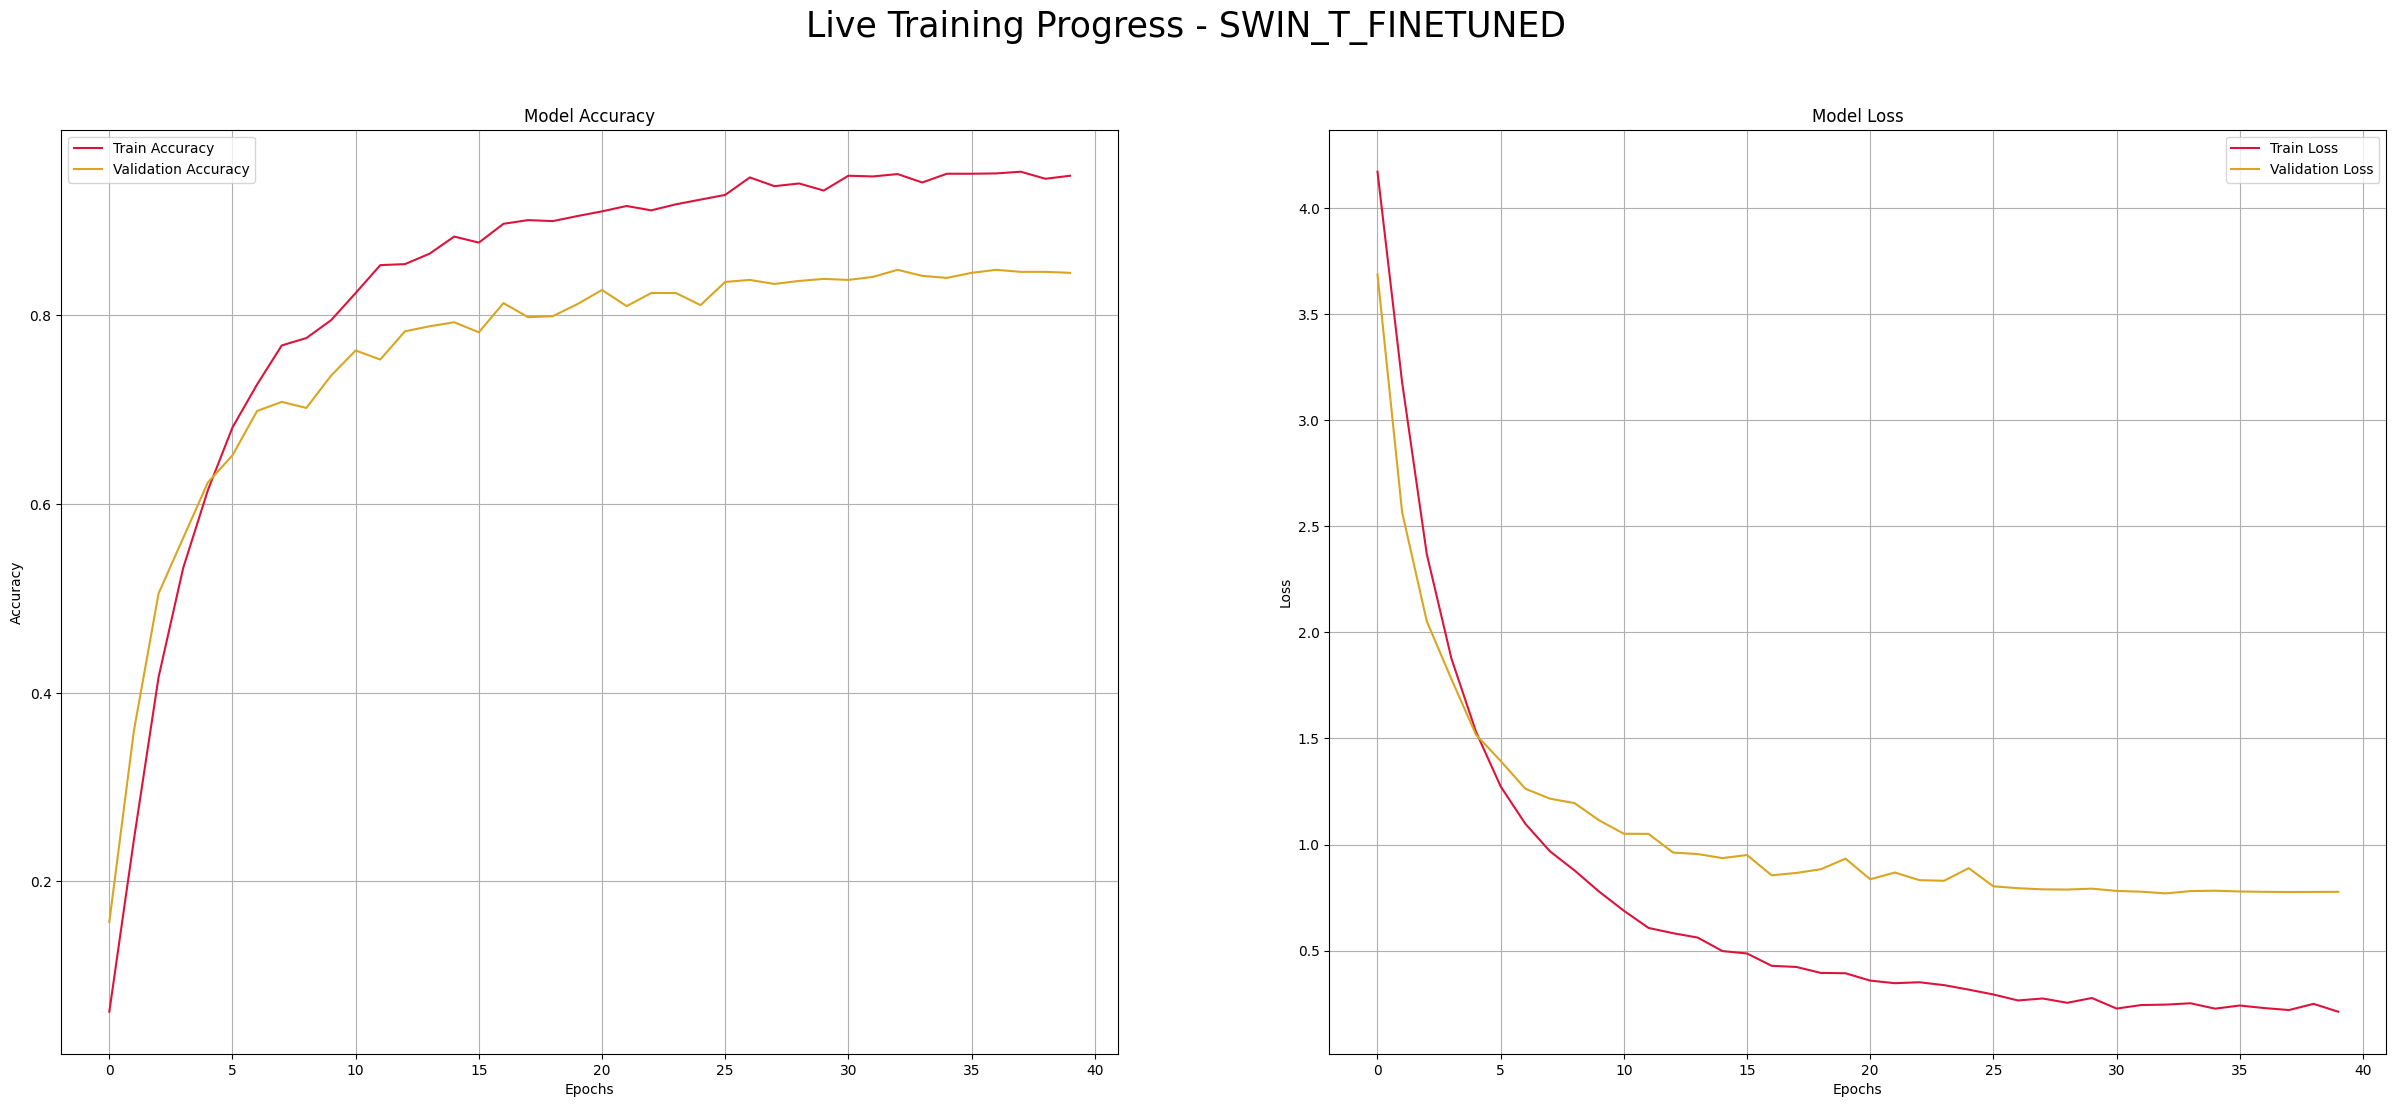

Epoch 40/50 -> Train Acc: 0.9480 | Val Acc: 0.8451
Early stopping triggered after 7 epochs with no improvement.

Training complete in 9m 14s
Best val Acc: 0.848291


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       1.00      1.00      1.00        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.85      0.92      0.88        12
      Amodis       0.86      1.00      0.92        12
     Atrizin       0.53      0.67      0.59        12
      Axodin       0.80      1.00      0.89        12
          Az       1.00      1.00      1.00        12
  Azithrocin       1.00      0.75      0.86        12
       Azyth       0.85      0.92      0.88        12
      Bacaid       0.80      1.00      0.89        12
    Backtone       0.90      0.75      0.82        12
    Baclofen       0.53      0.83      0.65        12
      Baclon       0.75      0.25      0.38        12
      Bacmax       1.00      0.83      0.91        12
       Beklo       0.86      1.00      0.92        12
     Bicozin       1.00      0.75      0.86        12
    Canazole       0.86      1.00      0.92        12
   

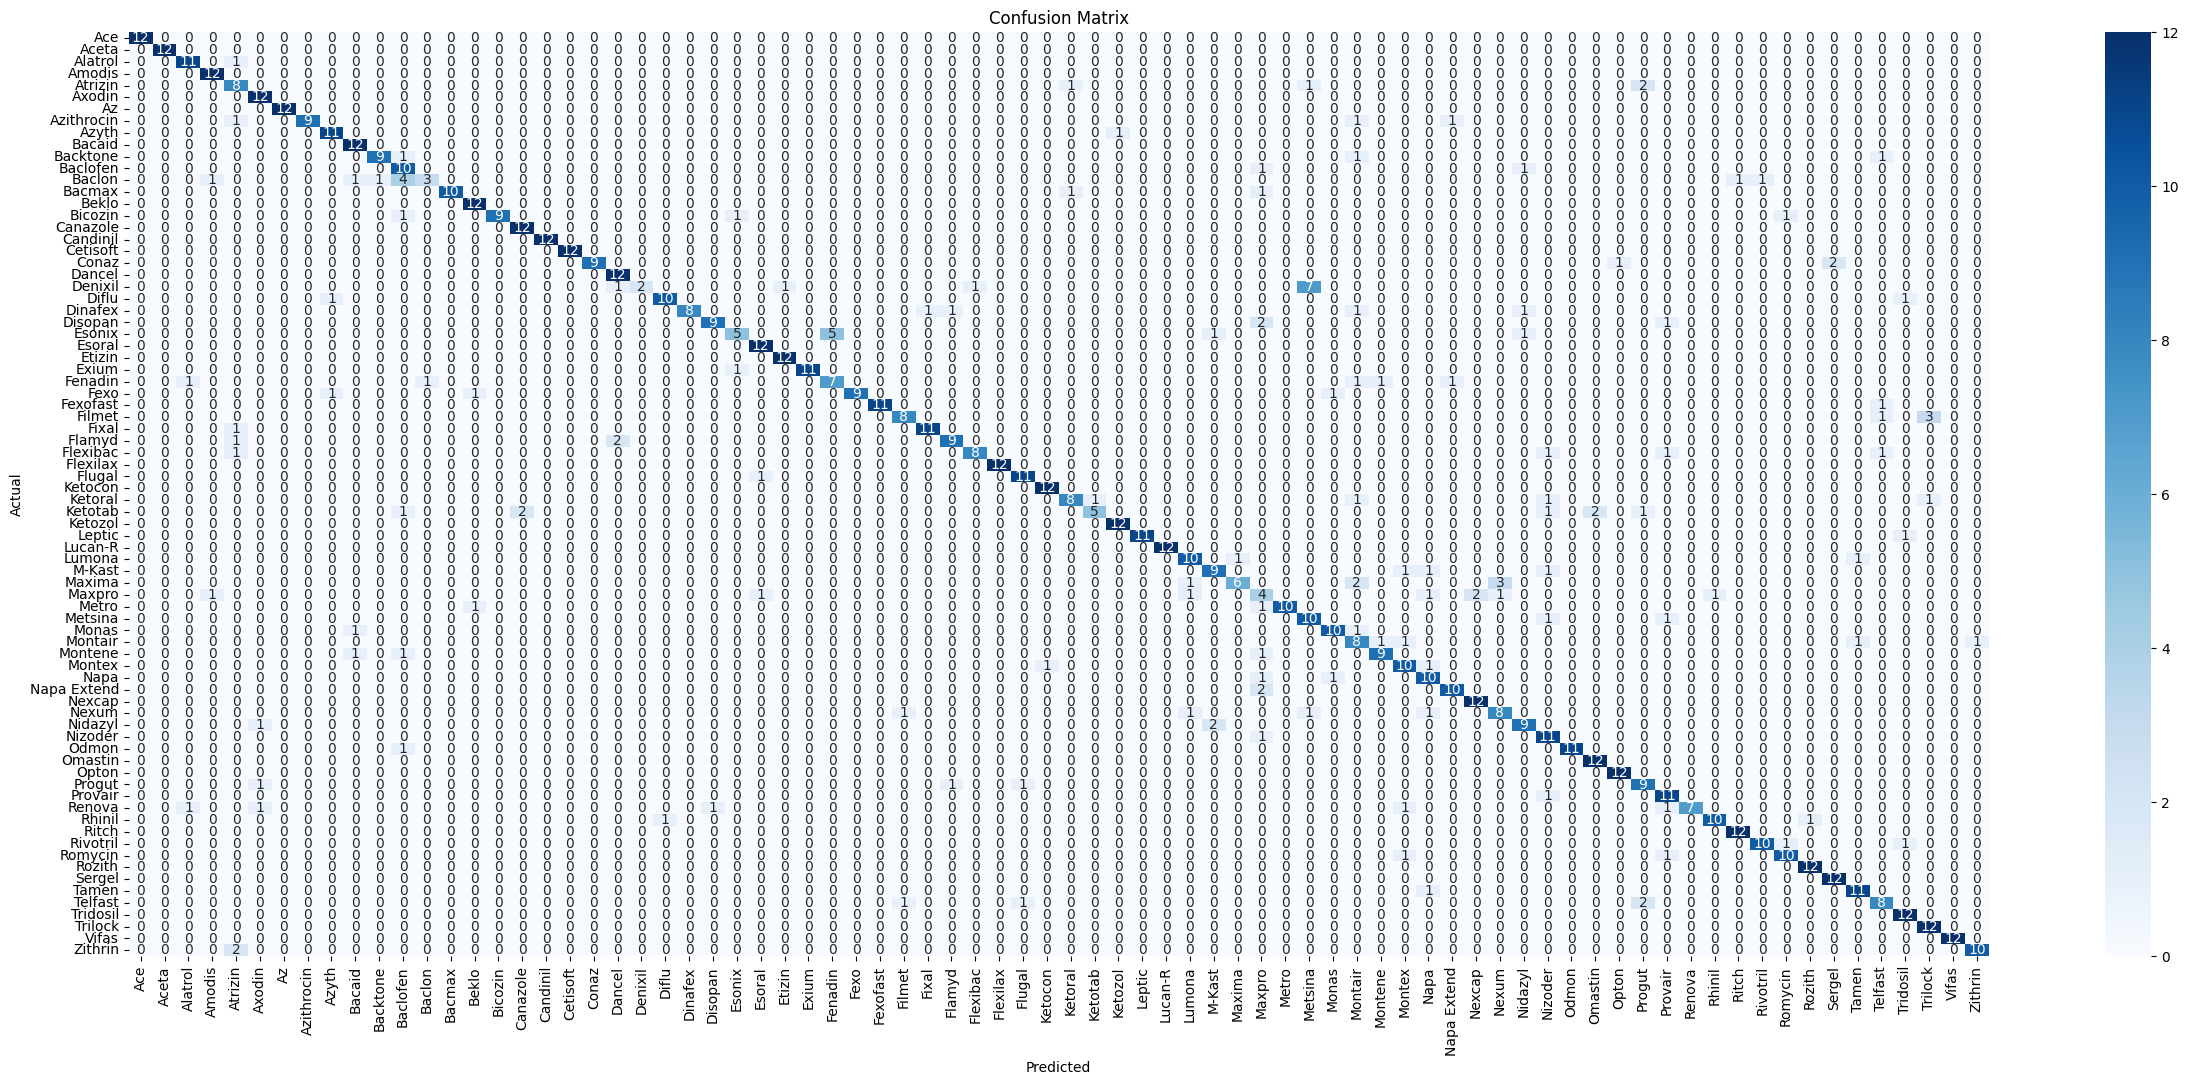

========== FINISHED EXPERIMENT: SWIN_T_FINETUNED ==========



In [14]:
# --- Experiment: Swin Transformer (Swin-T) with Fine-Tuning ---
print("\n--- Setting up Swin Transformer Experiment ---")
model_name = 'swin_t_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.swin_t(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last stage of the feature extractor and the head
for param in model.features[6:].parameters(): # Unfreezes stages 3 and 4
    param.requires_grad = True
for param in model.head.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.head.in_features
model.head = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

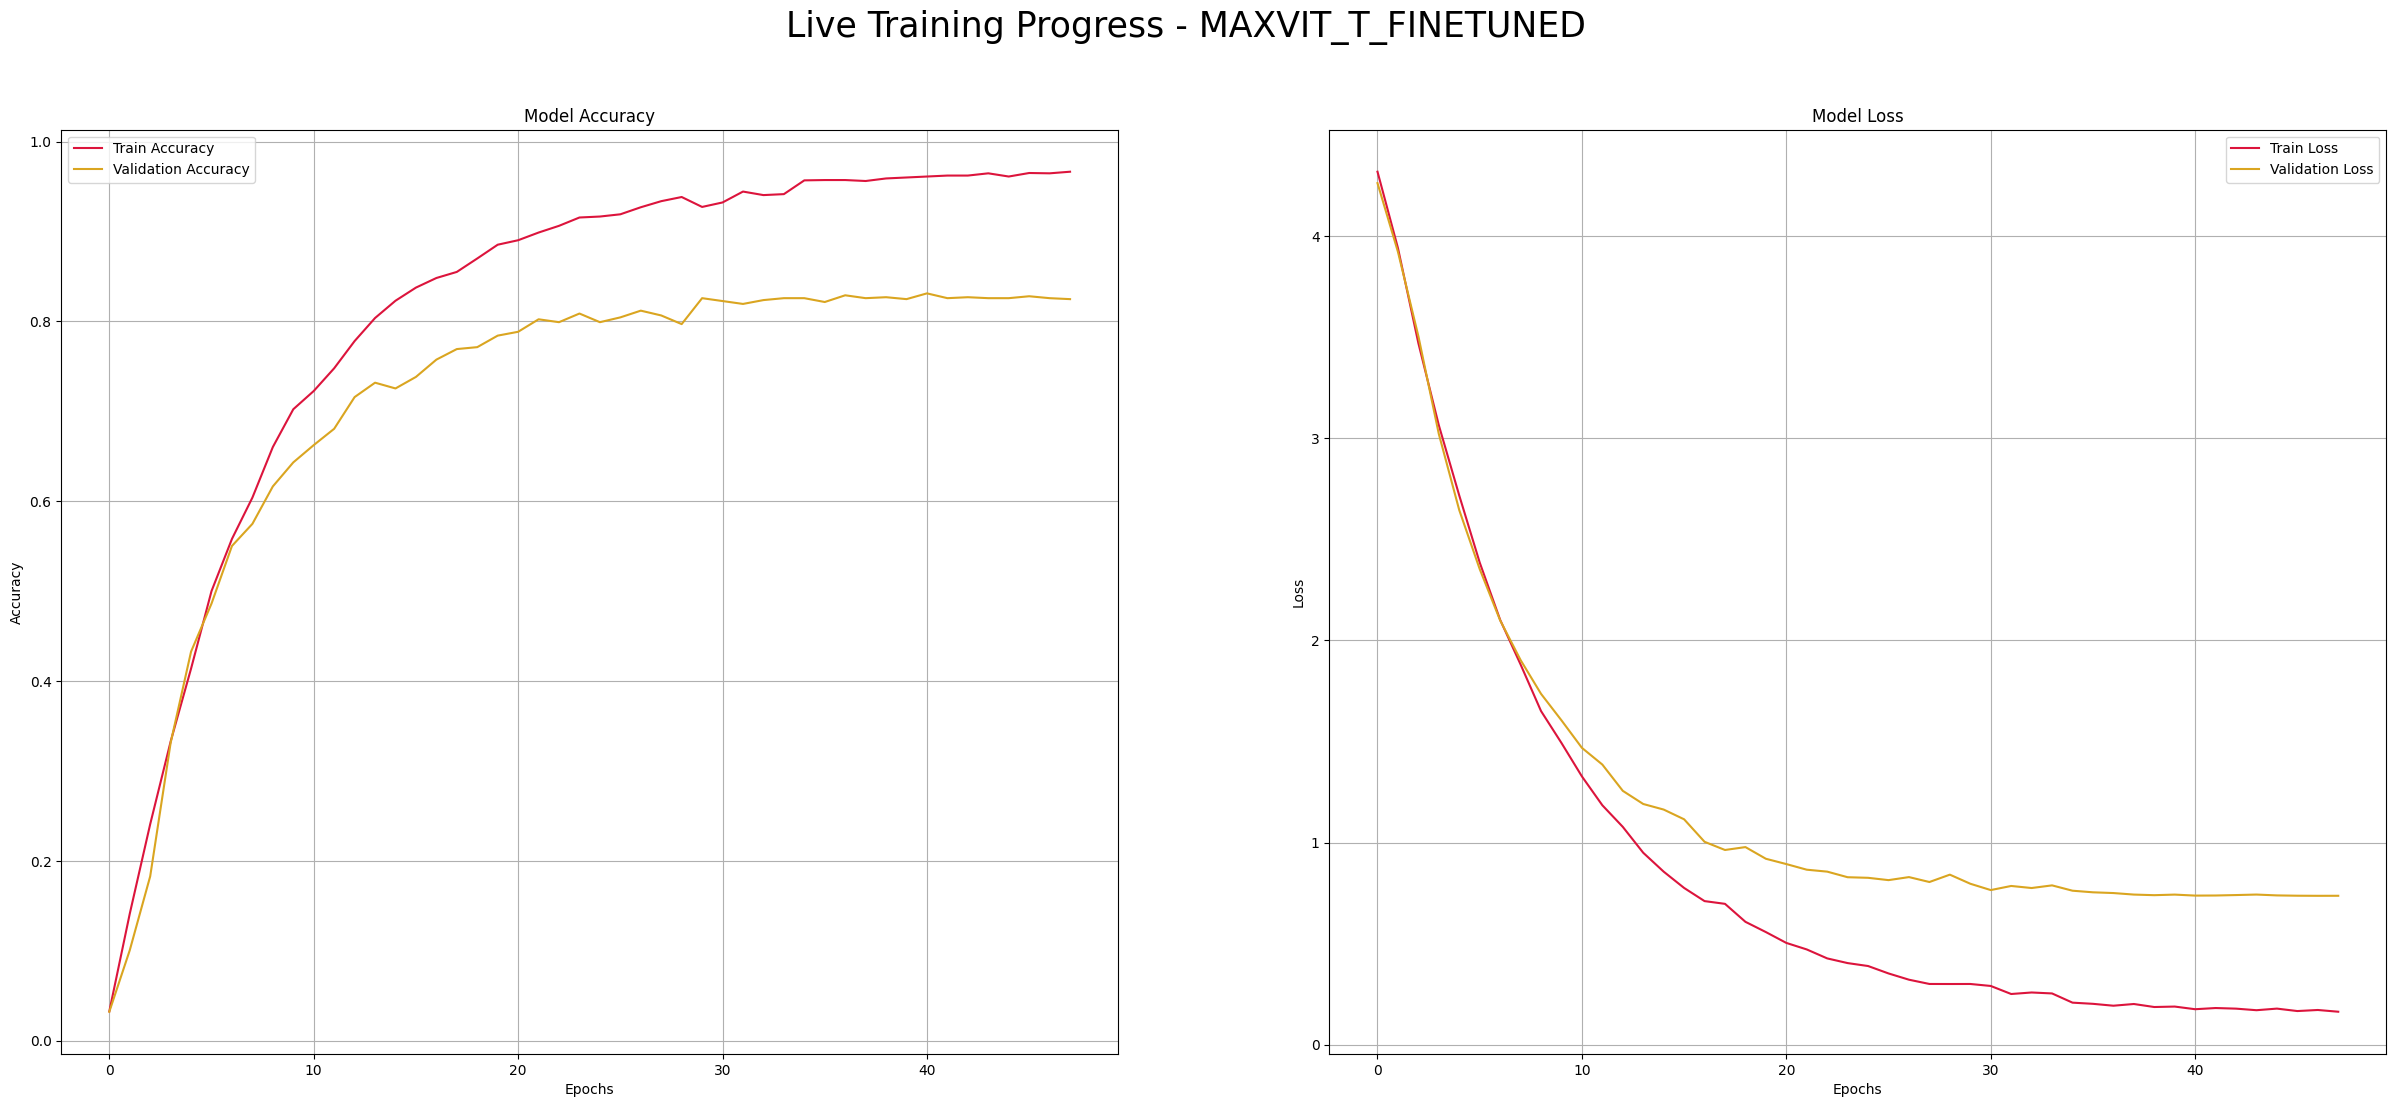

Epoch 48/50 -> Train Acc: 0.9665 | Val Acc: 0.8248
Early stopping triggered after 7 epochs with no improvement.

Training complete in 16m 47s
Best val Acc: 0.831197


Evaluating on Test Set:   0%|          | 0/30 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         Ace       1.00      1.00      1.00        12
       Aceta       1.00      1.00      1.00        12
     Alatrol       0.71      0.83      0.77        12
      Amodis       0.86      1.00      0.92        12
     Atrizin       0.62      0.67      0.64        12
      Axodin       0.73      0.92      0.81        12
          Az       1.00      1.00      1.00        12
  Azithrocin       0.62      0.83      0.71        12
       Azyth       1.00      1.00      1.00        12
      Bacaid       0.71      1.00      0.83        12
    Backtone       0.92      0.92      0.92        12
    Baclofen       0.73      0.67      0.70        12
      Baclon       0.75      0.25      0.38        12
      Bacmax       0.91      0.83      0.87        12
       Beklo       0.75      1.00      0.86        12
     Bicozin       0.91      0.83      0.87        12
    Canazole       0.92      1.00      0.96        12
   

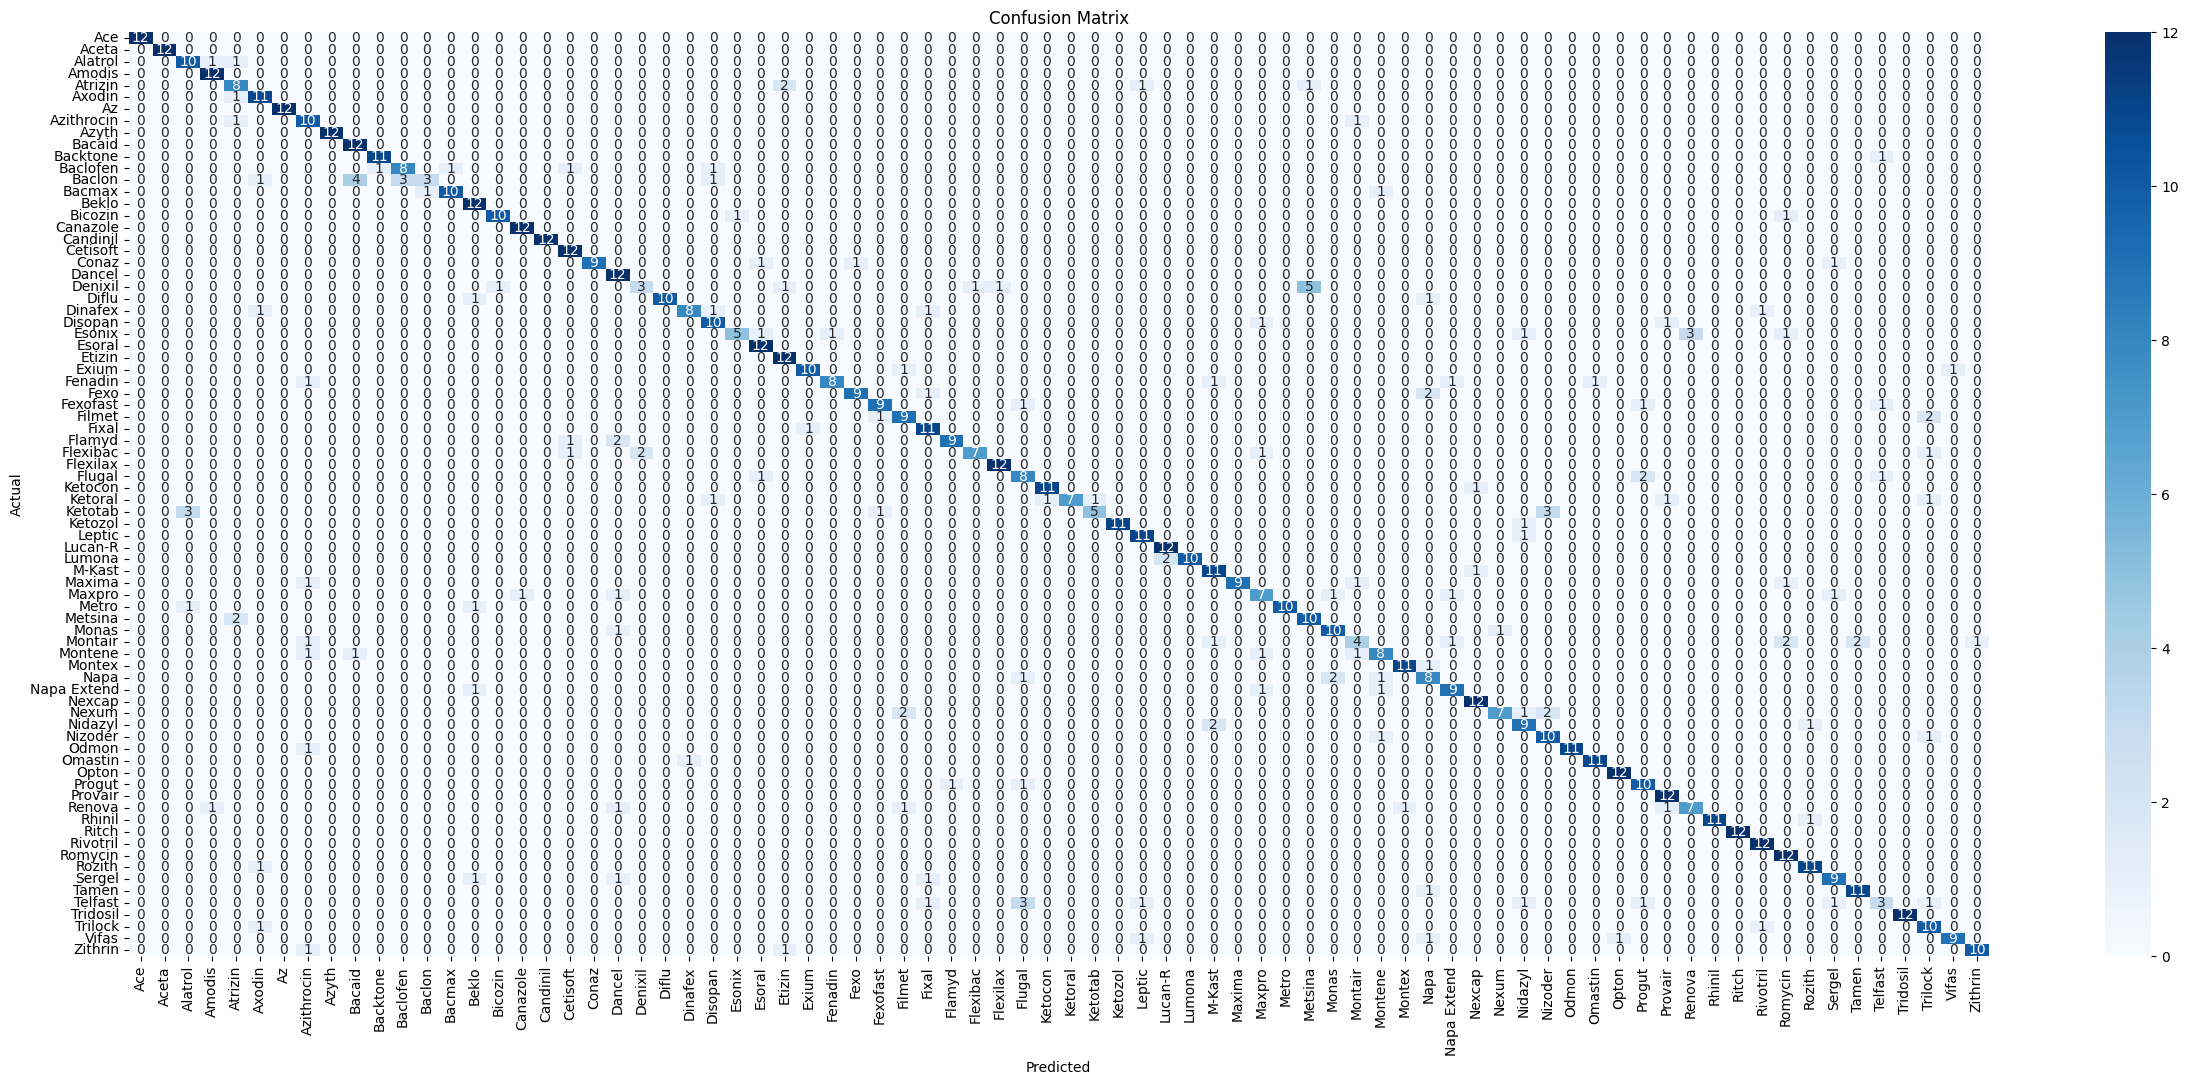

========== FINISHED EXPERIMENT: MAXVIT_T_FINETUNED ==========



In [15]:
# --- Experiment: MaxViT-Tiny with Fine-Tuning ---
print("\n--- Setting up MaxViT Experiment ---")
model_name = 'maxvit_t_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.maxvit_t(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last block of the feature extractor and the classifier
for param in model.blocks[3].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.classifier[5].in_features
model.classifier[5] = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

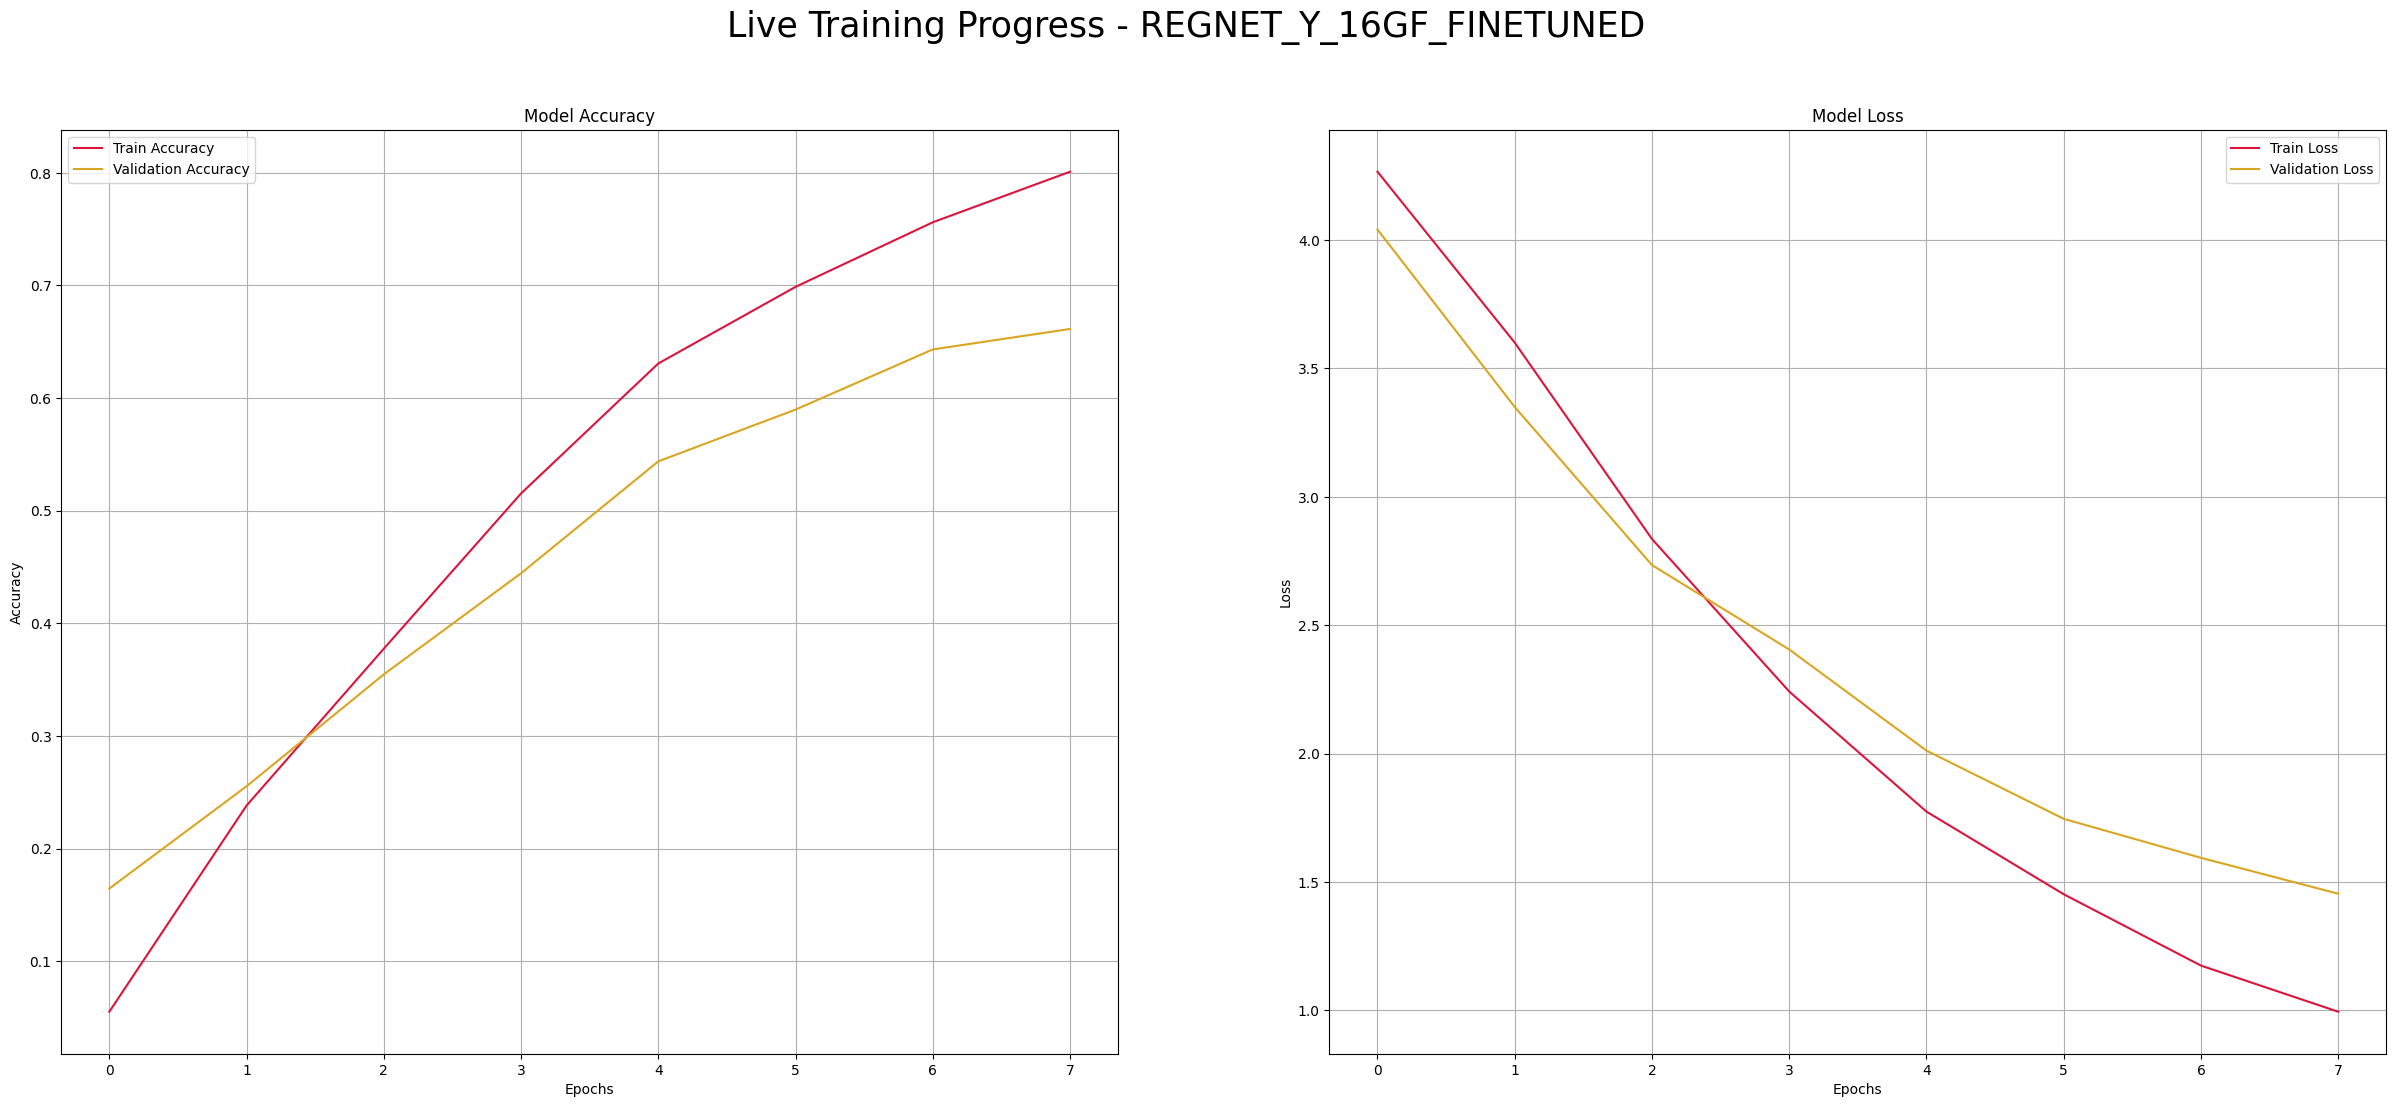

Epoch 8/50 -> Train Acc: 0.8009 | Val Acc: 0.6613


Train Epoch 9/50:   0%|          | 0/88 [00:00<?, ?it/s]

In [ ]:
# --- Experiment: RegNetY-16GF with Fine-Tuning ---
print("\n--- Setting up RegNet Experiment ---")
model_name = 'regnet_y_16gf_finetuned'
image_size = 224

# Get data loaders
dataloaders, dataset_sizes, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["valid_dir"], CONFIG["test_dir"], image_size, CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)

# Manually create and configure the model
model = models.regnet_y_16gf(weights='IMAGENET1K_V2')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze the last stage of the feature extractor and the classifier
for param in model.trunk_output.block4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True
    
# Replace the final layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Run the experiment
all_results[model_name] = run_experiment(model, model_name, dataloaders, dataset_sizes, class_names, CONFIG)

In [ ]:
# --- FINAL COMPARISON TABLE ---
results_df = pd.DataFrame({
    model: {
        "Peak Val Acc": max(res["history"]["val_acc"]),
        "Test Accuracy": res["test_accuracy"],
        "F1 (Macro)": res["f1_macro"],
        "AUC": res["auc"],
        "Kappa": res["kappa"],
    } for model, res in all_results.items()
}).T

print("\n\n--- FINAL COMPARISON TABLE ---")
display(results_df)
